# yahpo-gym Benchmark: HMM_MCMC_DREAM / HMM_MCMC_RAM / HMM_MCMC_GP_MALA / HMM_MCMC_BW / HMM_MCMC_TEST vs Optuna Bayesian Samplers

Сравнение алгоритмов **HMM_MCMC_DREAM** (DREAM + soft HMM + Baum-Welch), **HMM_MCMC_RAM** (BW + diagonal RAM on KDE mixture), **HMM_MCMC_GP_MALA** (BW + GP + MALA + RAM), **HMM_MCMC_BW** (Baum-Welch без spline) и **HMM_MCMC_TEST** из `hpo_rl` с байесовскими сэмплерами Optuna на surrogate-бенчмарках [yahpo-gym](https://github.com/slds-lmu/yahpo_gym).

**Алгоритмы:**
- `HMM_MCMC_DREAM` — DREAM(ZS) population proposals + soft forward-filtering HMM + Baum-Welch
- `HMM_MCMC_RAM` — Baum-Welch + diagonal RAM on KDE mixture
- `HMM_MCMC_GP_MALA` — Baum-Welch + GP surrogate + MALA + RAM
- `HMM_MCMC_BW` — Baum-Welch + стандартные Gaussian/KDE proposals
- `HMM_MCMC_TEST` — Baum-Welch + spline proposals
- Optuna: `TPESampler`, `GPSampler`, `BoTorchSampler` — каждый **без pruner** и **с HyperbandPruner** (BOHB-style)

**Сценарии:** `lcbench` (OpenML instances 3945, 7593, 126026), `rbv2_xgboost`, `nb301`

**Метрика:** максимизация validation accuracy (или аналог по сценарию).

**Бюджет / ось X:** суммарные fidelity-units (например, cumulative epochs), чтобы сравнение с pruner было честным.

**Выходные файлы:**
- `experiments/yahpo_plots/` — графики сходимости
- `experiments/yahpo_results/` — CSV, LaTeX, кэш кривых


In [1]:
# =============================================================================
# Configuration
# =============================================================================
from __future__ import annotations

from pathlib import Path
import json
import os

# Repo root (notebook lives in experiments/)
if Path.cwd().name == "experiments":
    REPO_ROOT = Path.cwd().parent
else:
    REPO_ROOT = Path.cwd()

# --- Scale: set SMOKE_MODE=False for the final paper run ---
SMOKE_MODE = False

# Progress bars (tqdm)
USE_TQDM = True
HMM_INNER_PROGRESS = False  # set True to keep HMM internal bar alongside outer tqdm

SEEDS = [42] if SMOKE_MODE else [42, 43, 44, 45, 46]
BUDGET_FIDELITY = 1040 if SMOKE_MODE else 10400  # 200 full evaluations x max_epoch(52) = 10400 fidelity units (single fidelity)

# Path to cloned https://github.com/slds-lmu/yahpo_data
DATA_PATH = Path(os.environ.get("YAHPO_DATA_PATH", REPO_ROOT / "yahpo_data"))

PLOTS_DIR = REPO_ROOT / "experiments" / "yahpo_plots"
RESULTS_DIR = REPO_ROOT / "experiments" / "yahpo_results"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# lcbench OpenML dataset IDs (each instance = different classification task)
# LCBENCH_INSTANCES = ["3945"] if SMOKE_MODE else ["3945", "7593", "126026"]
LCBENCH_INSTANCES = ["3945"] if SMOKE_MODE else ["7593", "189873", "168329", "167185", "167152"]
# LCBENCH_INSTANCES = ["3945"] if SMOKE_MODE else ["7593", "189873", "168329"]

LCBENCH_BASE = {
    "benchmark": "lcbench",
    "target": "val_accuracy",
    "fidelity": "epoch",
}

# Scenario metadata (instance / target / primary fidelity)
# Secondary fidelity params (e.g. rbv2 `repl`) are fixed to max at runtime.
SCENARIOS = {
    **{
        f"lcbench_{inst}": {**LCBENCH_BASE, "instance": inst}
        for inst in LCBENCH_INSTANCES
    },
    # "rbv2_xgboost": {
    #     "benchmark": "rbv2_xgboost",
    #     "instance": "40981",
    #     "target": "acc",
    #     "fidelity": "trainsize",
    # },
    # "nb301": {
    #     "benchmark": "nb301",
    #     "instance": "CIFAR10",
    #     "target": "val_accuracy",
    #     "fidelity": "epoch",
    # },
}

HYPERBAND_REDUCTION_FACTOR = 3
N_STARTUP_TRIALS = 10 if SMOKE_MODE else 20

# HMM hyperparameters tuned on lcbench (experiments/yahpo_tune_hmm_lcbench.ipynb)
HMM_TUNING_RESULTS = REPO_ROOT / "experiments" / "yahpo_tuning_results"


def _load_hmm_params(filename: str, default: dict | None = None) -> dict:
    path = HMM_TUNING_RESULTS / filename
    if not path.is_file():
        if default is not None:
            return dict(default)
        raise FileNotFoundError(f"Missing tuned params: {path}")
    with path.open(encoding="utf-8") as fh:
        return json.load(fh)


HMM_SHARED_FIXED = {
    "n_chains": 1,
    "orchestrate_every": 1000,
    "T_min": None,
    "hmm_obs_epsilon": 1e-8,
    "hmm_lambda_noise": 0.01,
    "rejection_streak": 10,
}

HMM_BW_DEFAULT = {
    "n_init": 32,
    "T_mcmc": 0.01,
    "sigma_fraction": 0.0055,
    "wide_sigma_fraction": 0.5,
    "temperature": 0.3,
    "hmm_window": 4,
    "clone_noise": 0.05,
    "burnin_fraction": 0.0,
    "p_cat_step": 0.30,
    "kde_tau": 0.05,
    "anneal_T": True,
    "use_baum_welch": True,
    "bw_refit_every": 5,
    "bw_min_obs": 12,
    "bw_prior_strength": 25.0,
    "bw_exploit_prior_scale": 3.0,
    "show_progress": False,
    "verbose_history": False,
}

HMM_BASE_PARAMS = {**HMM_SHARED_FIXED, **_load_hmm_params("best_params_hmm_mcmc.json")}
HMM_BW_PARAMS = {
    **HMM_SHARED_FIXED,
    **_load_hmm_params("best_params_hmm_mcmc_bw.json", default=HMM_BW_DEFAULT),
}
HMM_TEST_PARAMS = {**HMM_SHARED_FIXED, **_load_hmm_params("best_params_hmm_mcmc_test.json")}
HMM_DREAM_PARAMS = {
    **HMM_SHARED_FIXED,
    **_load_hmm_params("best_params_hmm_mcmc_dream.json"),
    "orchestrate_patience": 15,
}
HMM_RAM_DEFAULT = {
    **HMM_BW_DEFAULT,
    "use_ram": True,
    "ram_target_accept": 0.234,
    "ram_gamma": 0.7,
    "ram_s_min": 0.005,
    "ram_s_max": 0.5,
    "ram_precond_init": "archive",
}
HMM_RAM_PARAMS = {
    **HMM_SHARED_FIXED,
    **_load_hmm_params("best_params_hmm_mcmc_ram.json", default=HMM_RAM_DEFAULT),
}
HMM_GP_MALA_DEFAULT = {
    **HMM_BW_DEFAULT,
    "use_gp_mala": True,
    "n_init": 12,
    "ram_target_accept": 0.574,
    "ram_gamma": 0.7,
    "ram_s_min": 0.02,
    "ram_s_max": 0.5,
    "ram_precond_init": "archive",
    "gp_refit_every": 1,
    "gp_min_obs": 12,
    "gp_max_obs": 256,
    "gp_matern_nu": 2.5,
    "gp_kappa_exploit": 1.0,
    "gp_kappa_explore": 2.0,
    "gp_explore_mode": "thompson",
    "gp_target_temperature": 1.0,
    "gp_argmax_every": 1,
    "gp_argmax_restarts": 5,
    "gp_argmax_steps": 50,
    "mala_step_size": 0.1,
    "tr_enable": True,
    "tr_length_init": 0.8,
    "tr_length_min": 0.05,
    "tr_length_max": 1.6,
    "tr_success_tol": 3,
    "tr_failure_tol": 4,
    "tr_improve_tol": 0.001,
    "acq_anneal": True,
    "acq_greedy_after": 0.85,
    "tr_restart_candidates": 64,
    "tr_restart_kappa_start": 3.0,
    "tr_restart_kappa_end": 0.5,
    "bo_warmup_frac": 0.25,
}
HMM_GP_MALA_PARAMS = {
    **HMM_SHARED_FIXED,
    **_load_hmm_params("best_params_hmm_mcmc_gp_mala.json", default=HMM_GP_MALA_DEFAULT),
}

HMM_HMC_DEFAULT = {
    "n_init": 16,
    "rejection_streak": 10,
    "hmm_window": 8,
    "hmm_refit_every": 5,
    "hmm_min_obs": 12,
    "hmm_n_em_iters": 3,
    "hmm_prior_strength": 25.0,
    "gp_min_obs": 12,
    "gp_max_obs": 256,
    "gp_refit_every": 1,
    "gp_noise_floor": 1e-6,
    "kappa_exploit": 1.0,
    "kappa_explore": 3.0,
    "kappa_escape": 5.0,
    "T_exploit": 0.3,
    "T_explore": 1.0,
    "T_escape": 2.0,
    "step_size_init": 0.1,
    "target_accept": 0.8,
    "nuts_max_tree_depth": 10,
    "bo_warmup_frac": 0.25,
    "exploit_argmax_every": 1,
    "gp_argmax_restarts": 20,
    "gp_argmax_raw_samples": 256,
    "acq_greedy_after": 0.97,
    "explore_beta": 4.0,
    "gp_subsample": False,
    "burst_steps_escape": 64,
    "burst_steps_stuck": 32,
    "hmm_switch_confirm": 2,
    "p_cat_step": 0.0,
}
HMM_HMC_PARAMS = {
    **HMM_SHARED_FIXED,
    **_load_hmm_params("best_params_hmm_mcmc_hmc.json", default=HMM_HMC_DEFAULT),
}

ALGORITHMS = {
    "HMM_MCMC_DREAM": {"kind": "hmm", "variant": "dream"},
    # "HMM_MCMC_GP_MALA": {"kind": "hmm", "variant": "gp_mala"},
    # "HMM_MCMC_HMC": {"kind": "hmm", "variant": "hmc"},
    # "HMM_MCMC_RAM": {"kind": "hmm", "variant": "ram"},
    "HMM_MCMC_BW": {"kind": "hmm", "variant": "bw"},
    # "HMM_MCMC_TEST": {"kind": "hmm", "variant": "test"},
    "TPE": {"kind": "optuna", "sampler": "TPE", "pruner": False},
    # "TPE+Hyperband": {"kind": "optuna", "sampler": "TPE", "pruner": True},
    # "GP": {"kind": "optuna", "sampler": "GP", "pruner": False},
    # "GP+Hyperband": {"kind": "optuna", "sampler": "GP", "pruner": True},
    # "BoTorch": {"kind": "optuna", "sampler": "BoTorch", "pruner": False},
    # "BoTorch+Hyperband": {"kind": "optuna", "sampler": "BoTorch", "pruner": True},
}

ALGO_COLORS = {
    "HMM_MCMC_DREAM": "#9467bd",
    "HMM_MCMC_GP_MALA": "#e377c2",
    "HMM_MCMC_HMC": "#8c564b",
    "HMM_MCMC_RAM": "#bcbd22",
    "HMM_MCMC_BW": "#17becf",
    "HMM_MCMC_TEST": "#1f77b4",
    "TPE": "#ff7f0e",
    "TPE+Hyperband": "#ffbb78",
    "GP": "#2ca02c",
    "GP+Hyperband": "#98df8a",
    "BoTorch": "#d62728",
    "BoTorch+Hyperband": "#ff9896",
}

print(f"REPO_ROOT={REPO_ROOT}")
print(f"SMOKE_MODE={SMOKE_MODE}, SEEDS={SEEDS}, BUDGET_FIDELITY={BUDGET_FIDELITY}")
print(f"DATA_PATH={DATA_PATH}")
print(f"SCENARIOS={list(SCENARIOS.keys())}")


REPO_ROOT=c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL
SMOKE_MODE=False, SEEDS=[42, 43, 44, 45, 46], BUDGET_FIDELITY=10400
DATA_PATH=c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\yahpo_data
SCENARIOS=['lcbench_7593', 'lcbench_189873', 'lcbench_168329', 'lcbench_167185', 'lcbench_167152']


In [2]:
# =============================================================================
# Install missing deps + configure yahpo data path
# =============================================================================
import importlib
import subprocess
import sys

REQUIRED = [
    ("optuna", "optuna>=3.6"),
    ("optuna_integration", "optuna-integration"),
    ("botorch", "botorch"),
    ("gpytorch", "gpytorch"),
]


def _is_importable(module_name: str) -> bool:
    try:
        importlib.import_module(module_name)
        return True
    except ImportError:
        return False


missing = [spec for mod, spec in REQUIRED if not _is_importable(mod)]
if missing:
    print("Installing:", " ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])

from yahpo_gym import local_config

local_config.init_config() if not local_config.settings_path.exists() else None
local_config.set_data_path(str(DATA_PATH))

encoding_probe = DATA_PATH / "lcbench" / "encoding.json"
if not encoding_probe.is_file():
    raise FileNotFoundError(
        f"yahpo surrogate data not found at {DATA_PATH}.\n"
        "Clone the data repository, e.g.:\n"
        "  git clone https://github.com/slds-lmu/yahpo_data.git "
        f"{DATA_PATH}\n"
        "Or set YAHPO_DATA_PATH / edit DATA_PATH in the config cell."
    )

print("yahpo data OK:", encoding_probe)


yahpo data OK: c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\yahpo_data\lcbench\encoding.json


In [3]:
# =============================================================================
# Imports + repo bootstrap
# =============================================================================
import sys
import json
from dataclasses import dataclass, field
from typing import Any, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH

# yahpo-gym 1.0.1 calls ConfigurationSpace._sort_hyperparameters (removed in ConfigSpace 1.2+)
if not hasattr(CS.ConfigurationSpace, "_sort_hyperparameters"):
    CS.ConfigurationSpace._sort_hyperparameters = lambda self: None

import optuna
from optuna.samplers import TPESampler, GPSampler
from optuna.pruners import HyperbandPruner
from optuna_integration import BoTorchSampler
from yahpo_gym import benchmark_set

_root = str(REPO_ROOT)
if _root not in sys.path:
    sys.path.insert(0, _root)

from hpo_rl.baselines.HMM_MCMC import HMM_MCMC
from hpo_rl.baselines.HMM_MCMC_BW import HMM_MCMC_BW
from hpo_rl.baselines.HMM_MCMC_TEST import HMM_MCMC_TEST
from hpo_rl.baselines.HMM_MCMC_DREAM import HMM_MCMC_DREAM
from hpo_rl.baselines.HMM_MCMC_RAM import HMM_MCMC_RAM
from hpo_rl.baselines.HMM_MCMC_GP_MALA import HMM_MCMC_GP_MALA
from hpo_rl.baselines.HMM_MCMC_HMC import HMM_MCMC_HMC

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


In [4]:
# =============================================================================
# yahpo adapter helpers
# =============================================================================


@dataclass
class FidelityRecorder:
    """Tracks (cumulative_budget_units, raw_metric) events."""

    events: list[tuple[int, float]] = field(default_factory=list)
    cumulative: int = 0

    def record(self, cost: int, metric_value: float, full: bool = True) -> None:
        self.cumulative += int(cost)
        if full:
            self.events.append((self.cumulative, float(metric_value)))

    def best(self, maximize: bool = True) -> float:
        if not self.events:
            return float("nan")
        vals = [v for _, v in self.events if np.isfinite(v)]
        if not vals:
            return float("nan")
        return max(vals) if maximize else min(vals)


@dataclass
class ScenarioContext:
    key: str
    bench: Any
    target: str
    fidelity: str
    min_fidelity: float
    max_fidelity: float
    fidelity_is_int: bool
    full_eval_cost: int
    opt_space: CS.ConfigurationSpace
    hpo_rl_space: dict
    rungs: list[float]

    def fidelity_to_cost(self, value: float) -> int:
        """Map raw fidelity value -> integer budget units."""
        if self.fidelity_is_int:
            return max(1, int(round(value)))
        return max(1, int(round(float(value) / self.max_fidelity * self.full_eval_cost)))

    def cast_fidelity(self, value: float):
        if self.fidelity_is_int:
            return int(round(value))
        return float(value)


def _hp_bounds(hp: CSH.Hyperparameter) -> tuple[float, float]:
    return float(hp.lower), float(hp.upper)


def _hp_max_constant(hp: CSH.Hyperparameter):
    if isinstance(hp, CSH.UniformIntegerHyperparameter):
        return int(hp.upper)
    return float(hp.upper)


def configspace_to_hpo_rl_space(
    cs: CS.ConfigurationSpace,
    exclude: set[str] | None = None,
) -> dict:
    exclude = exclude or set()
    space: dict = {}
    for hp in cs.get_hyperparameters():
        name = hp.name
        if name in exclude or isinstance(hp, CSH.Constant):
            continue
        if isinstance(hp, CSH.UniformFloatHyperparameter):
            space[name] = {
                "type": "float",
                "values": [float(hp.lower), float(hp.upper)],
                "log": bool(hp.log),
            }
        elif isinstance(hp, CSH.UniformIntegerHyperparameter):
            space[name] = {
                "type": "int",
                "values": [int(hp.lower), int(hp.upper)],
                "log": bool(hp.log),
            }
        elif isinstance(hp, CSH.CategoricalHyperparameter):
            space[name] = {"type": "categorical", "values": list(hp.choices)}
        elif isinstance(hp, CSH.OrdinalHyperparameter):
            space[name] = {"type": "categorical", "values": list(hp.sequence)}
        else:
            raise TypeError(f"Unsupported hyperparameter type: {type(hp)} for {name}")
    return space


def pick_accuracy_target(targets: list[str], preferred: str | None = None) -> str:
    if preferred and preferred in targets:
        return preferred
    for name in targets:
        low = name.lower()
        if "accuracy" in low or low in {"acc", "bac", "balacc"}:
            return name
    return targets[0]


def generate_rungs(min_r: float, max_r: float, reduction_factor: int = 3) -> list[float]:
    """Geometric fidelity rungs for Hyperband (supports float fidelity like rbv2 trainsize)."""
    if min_r <= 0:
        raise ValueError(f"min_r must be > 0, got {min_r}")
    if max_r <= min_r:
        return [float(max_r)]

    rungs: list[float] = []
    r = float(min_r)
    while r < max_r - 1e-12:
        rungs.append(r)
        r *= reduction_factor
    rungs.append(float(max_r))
    # deduplicate with rounding for stable Optuna resources
    return sorted({round(x, 6) for x in rungs})


def make_benchmark(benchmark_name: str, instance: str) -> Any:
    bench = benchmark_set.BenchmarkSet(benchmark_name)
    if bench.config.instance_names is not None:
        bench.set_instance(instance)
    return bench


def build_scenario_context(scenario_key: str, cfg: dict) -> ScenarioContext:
    benchmark_name = cfg.get("benchmark", scenario_key)
    bench = make_benchmark(benchmark_name, cfg["instance"])
    # Disable strict checks for hierarchical / mixed spaces (HMM samples factorized)
    bench.check = False

    target = pick_accuracy_target(bench.targets, cfg.get("target"))
    fidelity = cfg["fidelity"]

    fspace = bench.get_fidelity_space()
    f_hp = fspace[fidelity]
    min_f, max_f = _hp_bounds(f_hp)
    fidelity_is_int = isinstance(f_hp, CSH.UniformIntegerHyperparameter)

    if fidelity_is_int:
        full_eval_cost = max(1, int(round(max_f)))
    else:
        # scale float fidelity (e.g. trainsize in [0.03, 1.0]) to integer budget units
        full_eval_cost = 100

    # Fix secondary fidelity dimensions to max (e.g. rbv2 `repl`)
    for fp in bench.config.fidelity_params:
        if fp == fidelity:
            continue
        hp2 = fspace[fp]
        bench.set_constant(fp, _hp_max_constant(hp2))

    opt_space = bench.get_opt_space(drop_fidelity_params=True)
    exclude = set(bench.config.fidelity_params)
    hpo_rl_space = configspace_to_hpo_rl_space(opt_space, exclude=exclude)

    rungs = generate_rungs(min_f, max_f, HYPERBAND_REDUCTION_FACTOR)

    return ScenarioContext(
        key=scenario_key,
        bench=bench,
        target=target,
        fidelity=fidelity,
        min_fidelity=min_f,
        max_fidelity=max_f,
        fidelity_is_int=fidelity_is_int,
        full_eval_cost=full_eval_cost,
        opt_space=opt_space,
        hpo_rl_space=hpo_rl_space,
        rungs=rungs,
    )


def suggest_config(trial: optuna.Trial, opt_space: CS.ConfigurationSpace) -> dict:
    config: dict = {}
    for hp in opt_space.get_hyperparameters():
        name = hp.name
        if isinstance(hp, CSH.Constant):
            config[name] = hp.value
        elif isinstance(hp, CSH.UniformFloatHyperparameter):
            config[name] = trial.suggest_float(name, hp.lower, hp.upper, log=hp.log)
        elif isinstance(hp, CSH.UniformIntegerHyperparameter):
            config[name] = trial.suggest_int(name, hp.lower, hp.upper, log=hp.log)
        elif isinstance(hp, CSH.CategoricalHyperparameter):
            config[name] = trial.suggest_categorical(name, list(hp.choices))
        elif isinstance(hp, CSH.OrdinalHyperparameter):
            config[name] = trial.suggest_categorical(name, list(hp.sequence))
        else:
            raise TypeError(f"Unsupported hyperparameter: {name} ({type(hp)})")
    return config


def evaluate_config(
    bench: Any,
    config: dict,
    fidelity_name: str,
    fidelity_value: float,
    target: str,
    *,
    fidelity_is_int: bool = True,
) -> float:
    cfg = dict(config)
    cfg[fidelity_name] = (
        int(round(fidelity_value)) if fidelity_is_int else float(fidelity_value)
    )
    result = bench.objective_function(cfg)[0]
    return float(result[target])


In [5]:
# =============================================================================
# Algorithm runners
# =============================================================================


def _make_sampler(name: str, seed: int):
    if name == "TPE":
        return TPESampler(seed=seed, n_startup_trials=N_STARTUP_TRIALS)
    if name == "GP":
        return GPSampler(seed=seed)
    if name == "BoTorch":
        return BoTorchSampler(seed=seed)
    raise ValueError(name)


def run_hmm_mcmc_dream(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    hmm_params: dict | None = None,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    n_evals = max(1, budget_fidelity // ctx.full_eval_cost)
    params = dict(HMM_DREAM_PARAMS)
    if hmm_params:
        params.update(hmm_params)
    if USE_TQDM and not HMM_INNER_PROGRESS:
        params["show_progress"] = False

    hmm_pbar = tqdm(
        total=n_evals,
        desc=f"DREAM {ctx.key} s={seed}",
        unit="eval",
        leave=False,
        disable=not USE_TQDM or HMM_INNER_PROGRESS,
    )

    def objective(config_dict: dict) -> float:
        raw = evaluate_config(
            ctx.bench,
            config_dict,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        recorder.record(ctx.full_eval_cost, raw)
        if not HMM_INNER_PROGRESS:
            hmm_pbar.update(1)
            hmm_pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        return -raw  # HMM minimizes

    np.random.seed(seed)
    alg = HMM_MCMC_DREAM(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        progress_desc=f"DREAM {ctx.key} seed={seed}",
        **params,
    )
    alg.main_loop()
    hmm_pbar.close()
    return recorder.events, recorder.best(maximize=True)




def run_hmm_mcmc_bw(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    hmm_params: dict | None = None,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    n_evals = max(1, budget_fidelity // ctx.full_eval_cost)
    params = dict(HMM_BW_PARAMS)
    if hmm_params:
        params.update(hmm_params)
    if USE_TQDM and not HMM_INNER_PROGRESS:
        params["show_progress"] = False

    hmm_pbar = tqdm(
        total=n_evals,
        desc=f"HMM-BW {ctx.key} s={seed}",
        unit="eval",
        leave=False,
        disable=not USE_TQDM or HMM_INNER_PROGRESS,
    )

    def objective(config_dict: dict) -> float:
        raw = evaluate_config(
            ctx.bench,
            config_dict,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        recorder.record(ctx.full_eval_cost, raw)
        if not HMM_INNER_PROGRESS:
            hmm_pbar.update(1)
            hmm_pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        return -raw  # HMM minimizes

    np.random.seed(seed)
    alg = HMM_MCMC_BW(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        progress_desc=f"HMM-BW {ctx.key} seed={seed}",
        **params,
    )
    alg.main_loop()
    hmm_pbar.close()
    return recorder.events, recorder.best(maximize=True)


def run_hmm_mcmc_ram(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    hmm_params: dict | None = None,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    n_evals = max(1, budget_fidelity // ctx.full_eval_cost)
    params = dict(HMM_RAM_PARAMS)
    if hmm_params:
        params.update(hmm_params)
    if USE_TQDM and not HMM_INNER_PROGRESS:
        params["show_progress"] = False

    hmm_pbar = tqdm(
        total=n_evals,
        desc=f"HMM-RAM {ctx.key} s={seed}",
        unit="eval",
        leave=False,
        disable=not USE_TQDM or HMM_INNER_PROGRESS,
    )

    def objective(config_dict: dict) -> float:
        raw = evaluate_config(
            ctx.bench,
            config_dict,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        recorder.record(ctx.full_eval_cost, raw)
        if not HMM_INNER_PROGRESS:
            hmm_pbar.update(1)
            hmm_pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        return -raw

    np.random.seed(seed)
    alg = HMM_MCMC_RAM(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        progress_desc=f"HMM-RAM {ctx.key} seed={seed}",
        **params,
    )
    alg.main_loop()
    hmm_pbar.close()
    return recorder.events, recorder.best(maximize=True)


def run_hmm_mcmc_gp_mala(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    hmm_params: dict | None = None,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    n_evals = max(1, budget_fidelity // ctx.full_eval_cost)
    params = dict(HMM_GP_MALA_PARAMS)
    if hmm_params:
        params.update(hmm_params)
    if USE_TQDM and not HMM_INNER_PROGRESS:
        params["show_progress"] = False

    hmm_pbar = tqdm(
        total=n_evals,
        desc=f"HMM-GP-MALA {ctx.key} s={seed}",
        unit="eval",
        leave=False,
        disable=not USE_TQDM or HMM_INNER_PROGRESS,
    )

    def objective(config_dict: dict) -> float:
        raw = evaluate_config(
            ctx.bench,
            config_dict,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        recorder.record(ctx.full_eval_cost, raw)
        if not HMM_INNER_PROGRESS:
            hmm_pbar.update(1)
            hmm_pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        return -raw

    np.random.seed(seed)
    alg = HMM_MCMC_GP_MALA(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        progress_desc=f"HMM-GP-MALA {ctx.key} seed={seed}",
        **params,
    )
    alg.main_loop()
    hmm_pbar.close()
    return recorder.events, recorder.best(maximize=True)


def run_hmm_mcmc_hmc(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    hmm_params: dict | None = None,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    n_evals = max(1, budget_fidelity // ctx.full_eval_cost)
    params = dict(HMM_HMC_PARAMS)
    if hmm_params:
        params.update(hmm_params)
    if USE_TQDM and not HMM_INNER_PROGRESS:
        params["show_progress"] = False

    hmm_pbar = tqdm(
        total=n_evals,
        desc=f"HMM-HMC {ctx.key} s={seed}",
        unit="eval",
        leave=False,
        disable=not USE_TQDM or HMM_INNER_PROGRESS,
    )

    def objective(config_dict: dict) -> float:
        raw = evaluate_config(
            ctx.bench,
            config_dict,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        finite_raw = np.isfinite(raw)
        record_metric = float(raw) if finite_raw else 0.0
        recorder.record(ctx.full_eval_cost, record_metric)
        if not HMM_INNER_PROGRESS:
            hmm_pbar.update(1)
            hmm_pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        return -record_metric if finite_raw else 1e6

    np.random.seed(seed)
    alg = HMM_MCMC_HMC(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        progress_desc=f"HMM-HMC {ctx.key} seed={seed}",
        seed=seed,
        **params,
    )
    alg.main_loop()
    hmm_pbar.close()
    return recorder.events, recorder.best(maximize=True)


def run_hmm_mcmc_test(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    hmm_params: dict | None = None,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    n_evals = max(1, budget_fidelity // ctx.full_eval_cost)
    params = dict(HMM_TEST_PARAMS)
    if hmm_params:
        params.update(hmm_params)
    if USE_TQDM and not HMM_INNER_PROGRESS:
        params["show_progress"] = False

    hmm_pbar = tqdm(
        total=n_evals,
        desc=f"HMM {ctx.key} s={seed}",
        unit="eval",
        leave=False,
        disable=not USE_TQDM or HMM_INNER_PROGRESS,
    )

    def objective(config_dict: dict) -> float:
        raw = evaluate_config(
            ctx.bench,
            config_dict,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        recorder.record(ctx.full_eval_cost, raw)
        if not HMM_INNER_PROGRESS:
            hmm_pbar.update(1)
            hmm_pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        return -raw  # HMM minimizes

    np.random.seed(seed)
    alg = HMM_MCMC_TEST(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        progress_desc=f"HMM {ctx.key} seed={seed}",
        **params,
    )
    alg.main_loop()
    hmm_pbar.close()
    return recorder.events, recorder.best(maximize=True)


def run_hmm_mcmc(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    hmm_params: dict | None = None,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    n_evals = max(1, budget_fidelity // ctx.full_eval_cost)
    params = dict(HMM_BASE_PARAMS)
    if hmm_params:
        params.update(hmm_params)

    hmm_pbar = tqdm(
        total=n_evals,
        desc=f"HMM-base {ctx.key} s={seed}",
        unit="eval",
        leave=False,
        disable=not USE_TQDM,
    )

    def objective(config_dict: dict) -> float:
        raw = evaluate_config(
            ctx.bench,
            config_dict,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        recorder.record(ctx.full_eval_cost, raw)
        hmm_pbar.update(1)
        hmm_pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        return -raw

    np.random.seed(seed)
    alg = HMM_MCMC(
        objective_func=objective,
        budget=n_evals,
        dict_to_optimize=ctx.hpo_rl_space,
        **params,
    )
    alg.main_loop()
    hmm_pbar.close()
    return recorder.events, recorder.best(maximize=True)


def run_optuna(
    ctx: ScenarioContext,
    budget_fidelity: int,
    seed: int,
    sampler_name: str,
    use_pruner: bool,
) -> tuple[list[tuple[int, float]], float]:
    recorder = FidelityRecorder()
    sampler = _make_sampler(sampler_name, seed)
    pruner = (
        HyperbandPruner(
            min_resource=ctx.fidelity_to_cost(ctx.min_fidelity),
            max_resource=ctx.full_eval_cost,
            reduction_factor=HYPERBAND_REDUCTION_FACTOR,
        )
        if use_pruner
        else None
    )
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)

    label = f"{sampler_name}{'+HB' if use_pruner else ''} {ctx.key} s={seed}"
    pbar = tqdm(
        total=budget_fidelity,
        desc=label,
        unit="fid",
        leave=False,
        disable=not USE_TQDM,
    )

    def objective(trial: optuna.Trial) -> float:
        config = suggest_config(trial, ctx.opt_space)
        if use_pruner:
            last_val = float("-inf")
            prev_cost = 0
            for step in ctx.rungs:
                val = evaluate_config(
                    ctx.bench,
                    config,
                    ctx.fidelity,
                    step,
                    ctx.target,
                    fidelity_is_int=ctx.fidelity_is_int,
                )
                cost_abs = ctx.fidelity_to_cost(step)
                inc = max(1, cost_abs - prev_cost)
                prev_cost = cost_abs
                is_full = step == ctx.rungs[-1]
                recorder.record(inc, val, full=is_full)
                trial.report(val, cost_abs)
                if trial.should_prune():
                    raise optuna.TrialPruned()
                last_val = val
                if recorder.cumulative >= budget_fidelity:
                    break
            return last_val
        val = evaluate_config(
            ctx.bench,
            config,
            ctx.fidelity,
            ctx.max_fidelity,
            ctx.target,
            fidelity_is_int=ctx.fidelity_is_int,
        )
        recorder.record(ctx.full_eval_cost, val)
        return val

    while recorder.cumulative < budget_fidelity:
        trial = study.ask()
        try:
            value = objective(trial)
            study.tell(trial, value)
        except optuna.TrialPruned:
            study.tell(trial, state=optuna.trial.TrialState.PRUNED)
        pbar.n = min(recorder.cumulative, budget_fidelity)
        pbar.set_postfix(best=f"{recorder.best(maximize=True):.4f}", refresh=False)
        pbar.refresh()
        if recorder.cumulative >= budget_fidelity:
            break

    pbar.close()
    return recorder.events, recorder.best(maximize=True)


def run_algorithm(
    algo_name: str,
    spec: dict,
    ctx: ScenarioContext,
    seed: int,
    budget_fidelity: int,
) -> tuple[list[tuple[int, float]], float]:
    if spec["kind"] == "hmm":
        variant = spec.get("variant", "test")
        if variant == "dream":
            return run_hmm_mcmc_dream(ctx, budget_fidelity, seed)
        if variant == "ram":
            return run_hmm_mcmc_ram(ctx, budget_fidelity, seed)
        if variant == "gp_mala":
            return run_hmm_mcmc_gp_mala(ctx, budget_fidelity, seed)
        if variant == "hmc":
            return run_hmm_mcmc_hmc(ctx, budget_fidelity, seed)
        if variant == "base":
            return run_hmm_mcmc(ctx, budget_fidelity, seed)
        if variant == "bw":
            return run_hmm_mcmc_bw(ctx, budget_fidelity, seed)
        return run_hmm_mcmc_test(ctx, budget_fidelity, seed)
    return run_optuna(
        ctx,
        budget_fidelity,
        seed,
        sampler_name=spec["sampler"],
        use_pruner=spec["pruner"],
    )


In [6]:
# =============================================================================
# Curve aggregation utilities
# =============================================================================


def events_to_best_curve(
    events: list[tuple[int, float]],
    budget_fidelity: int,
    maximize: bool = True,
) -> np.ndarray:
    """Map fidelity events -> best-so-far curve on grid 1..budget_fidelity."""
    grid = np.arange(1, budget_fidelity + 1, dtype=float)
    curve = np.full(budget_fidelity, np.nan, dtype=float)
    if not events:
        return curve

    events = sorted(events, key=lambda x: x[0])
    best = -np.inf if maximize else np.inf
    idx = 0
    for gi, fid in enumerate(grid):
        while idx < len(events) and events[idx][0] <= fid:
            val = events[idx][1]
            best = max(best, val) if maximize else min(best, val)
            idx += 1
        if np.isfinite(best) and best not in (-np.inf, np.inf):
            curve[gi] = best

    # forward-fill leading NaNs
    first_finite = np.where(np.isfinite(curve))[0]
    if len(first_finite):
        curve[: first_finite[0]] = curve[first_finite[0]]
        for i in range(1, len(curve)):
            if not np.isfinite(curve[i]):
                curve[i] = curve[i - 1]
    return curve


def aggregate_curves(curves: list[np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    stack = np.vstack(curves)
    return np.nanmean(stack, axis=0), np.nanstd(stack, axis=0)


In [7]:
# =============================================================================
# Main experiment loop
# =============================================================================

# Resolve scenario contexts once
contexts: dict[str, ScenarioContext] = {}
for sc_key, sc_cfg in tqdm(
    list(SCENARIOS.items()),
    desc="Building scenario contexts",
    disable=not USE_TQDM,
):
    ctx = build_scenario_context(sc_key, sc_cfg)
    contexts[sc_key] = ctx
    print(
        f"{sc_key}: instance={sc_cfg['instance']}, target={ctx.target}, "
        f"fidelity={ctx.fidelity} in [{ctx.min_fidelity}, {ctx.max_fidelity}], "
        f"full_eval_cost={ctx.full_eval_cost}, rungs={ctx.rungs}, n_hp={len(ctx.hpo_rl_space)}"
    )

# results[scenario][algo] = list of curves (one per seed)
results_curves: dict[str, dict[str, list[np.ndarray]]] = {
    sc: {algo: [] for algo in ALGORITHMS} for sc in SCENARIOS
}
results_final: dict[str, dict[str, list[float]]] = {
    sc: {algo: [] for algo in ALGORITHMS} for sc in SCENARIOS
}

runs = [
    (sc_key, algo_name, spec, seed)
    for sc_key, ctx in contexts.items()
    for algo_name, spec in ALGORITHMS.items()
    for seed in SEEDS
]

pbar = tqdm(runs, desc="All experiments", unit="run", disable=not USE_TQDM)
for sc_key, algo_name, spec, seed in pbar:
    ctx = contexts[sc_key]
    pbar.set_postfix(scenario=sc_key, algo=algo_name, seed=seed, refresh=False)
    events, best_val = run_algorithm(
        algo_name, spec, ctx, seed=seed, budget_fidelity=BUDGET_FIDELITY
    )
    curve = events_to_best_curve(events, BUDGET_FIDELITY, maximize=True)
    results_curves[sc_key][algo_name].append(curve)
    results_final[sc_key][algo_name].append(best_val)
    pbar.set_postfix(
        scenario=sc_key,
        algo=algo_name,
        seed=seed,
        best=f"{best_val:.4f}",
        refresh=True,
    )

# Cache raw curves for re-plotting
cache_path = RESULTS_DIR / "raw_curves.npz"
np.savez_compressed(
    cache_path,
    budget_fidelity=BUDGET_FIDELITY,
    seeds=np.array(SEEDS),
    scenarios=np.array(list(SCENARIOS.keys())),
    algorithms=np.array(list(ALGORITHMS.keys())),
    **{
        f"curve__{sc}__{algo}": np.vstack(results_curves[sc][algo])
        for sc in SCENARIOS
        for algo in ALGORITHMS
    },
    **{
        f"final__{sc}__{algo}": np.array(results_final[sc][algo])
        for sc in SCENARIOS
        for algo in ALGORITHMS
    },
)
print(f"\nCached curves -> {cache_path}")


Building scenario contexts:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\.venv\Lib\site-packages\ConfigSpace\configuration_space.py:1038: UserWarning: The field 'default' should be 'default_value' !
Found in item {'name': 'OpenML_task_id', 'choices': ['3945', '7593', '34539', '126025', '126026', '126029', '146212', '167104', '167149', '167152', '167161', '167168', '167181', '167184', '167185', '167190', '167200', '167201', '168329', '168330', '168331', '168335', '168868', '168908', '168910', '189354', '189862', '189865', '189866', '189873', '189905', '189906', '189908', '189909'], 'probabilities': None}
  return decoder(item, cs, _dec)
c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\.venv\Lib\site-packages\ConfigSpace\configuration_space.py:1038: UserWarning: The field 'default' should be 'default_value' !
Found in item {'name': 'batch_size', 'log': True, 'lower': 16, 'upper': 512}
  return decoder(item, cs, _dec)
c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\.venv\Lib\site-pack

lcbench_7593: instance=7593, target=val_accuracy, fidelity=epoch in [1.0, 52.0], full_eval_cost=52, rungs=[1.0, 3.0, 9.0, 27.0, 52.0], n_hp=7
lcbench_189873: instance=189873, target=val_accuracy, fidelity=epoch in [1.0, 52.0], full_eval_cost=52, rungs=[1.0, 3.0, 9.0, 27.0, 52.0], n_hp=7
lcbench_168329: instance=168329, target=val_accuracy, fidelity=epoch in [1.0, 52.0], full_eval_cost=52, rungs=[1.0, 3.0, 9.0, 27.0, 52.0], n_hp=7
lcbench_167185: instance=167185, target=val_accuracy, fidelity=epoch in [1.0, 52.0], full_eval_cost=52, rungs=[1.0, 3.0, 9.0, 27.0, 52.0], n_hp=7
lcbench_167152: instance=167152, target=val_accuracy, fidelity=epoch in [1.0, 52.0], full_eval_cost=52, rungs=[1.0, 3.0, 9.0, 27.0, 52.0], n_hp=7


All experiments:   0%|          | 0/75 [00:00<?, ?run/s]

DREAM lcbench_7593 s=42:   0%|          | 0/200 [00:00<?, ?eval/s]

...

TPE lcbench_167152 s=43:   0%|          | 0/10400 [00:00<?, ?fid/s]

TPE lcbench_167152 s=44:   0%|          | 0/10400 [00:00<?, ?fid/s]

TPE lcbench_167152 s=45:   0%|          | 0/10400 [00:00<?, ?fid/s]

TPE lcbench_167152 s=46:   0%|          | 0/10400 [00:00<?, ?fid/s]


Cached curves -> c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\raw_curves.npz


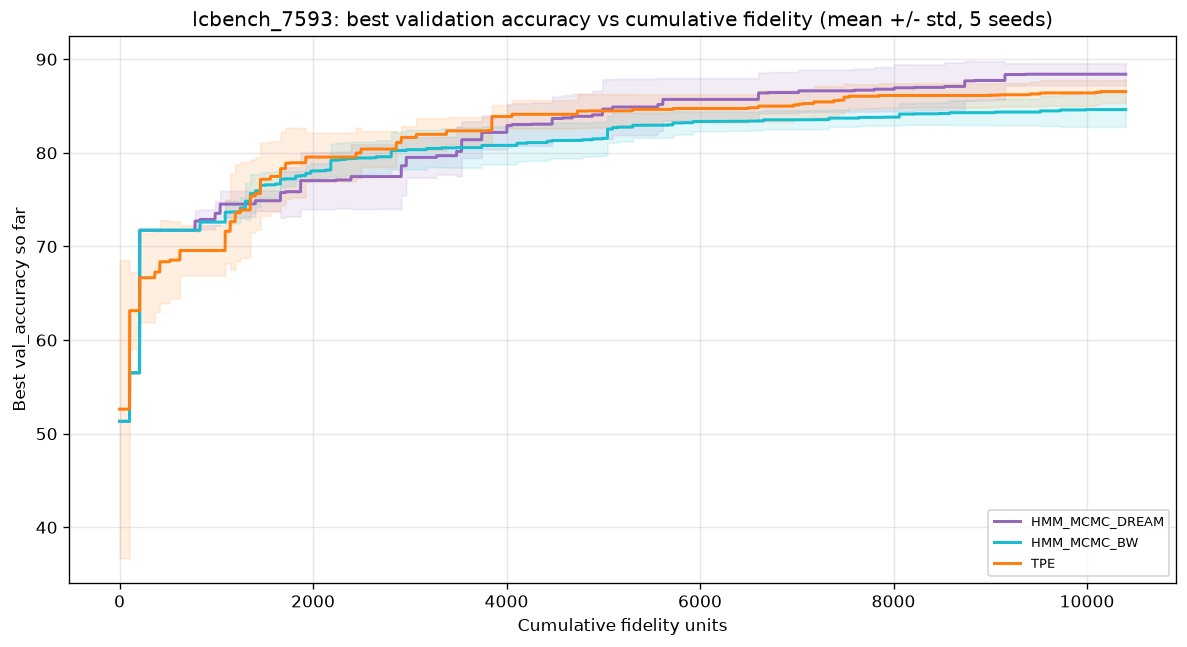

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\convergence_lcbench_7593.png


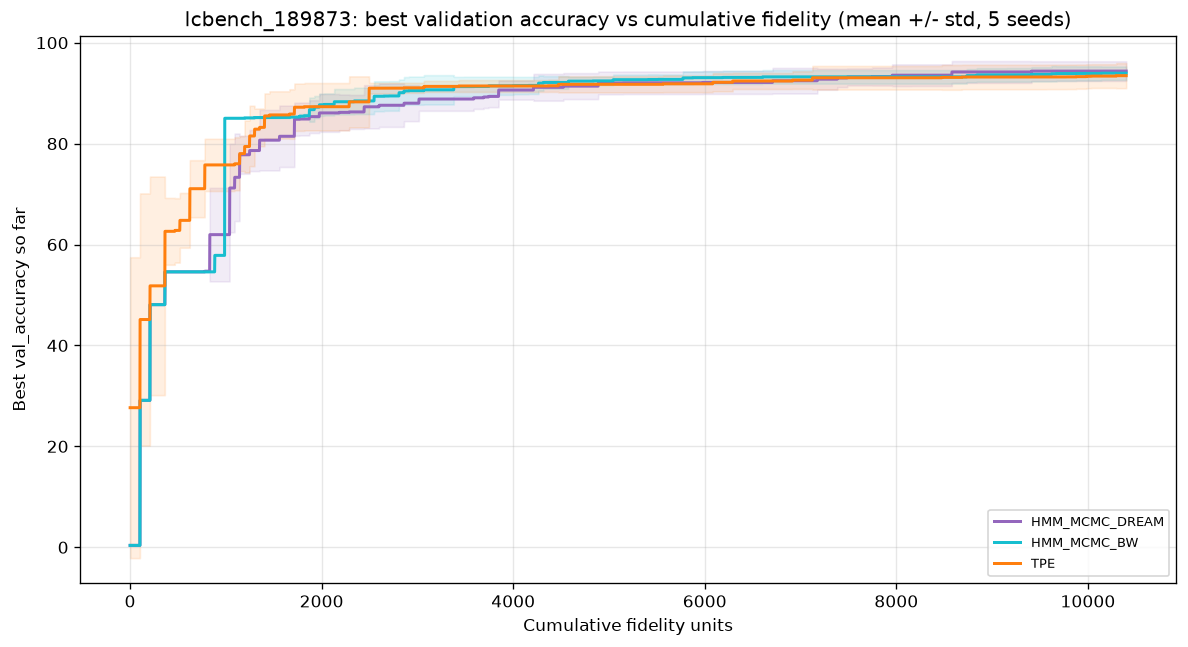

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\convergence_lcbench_189873.png


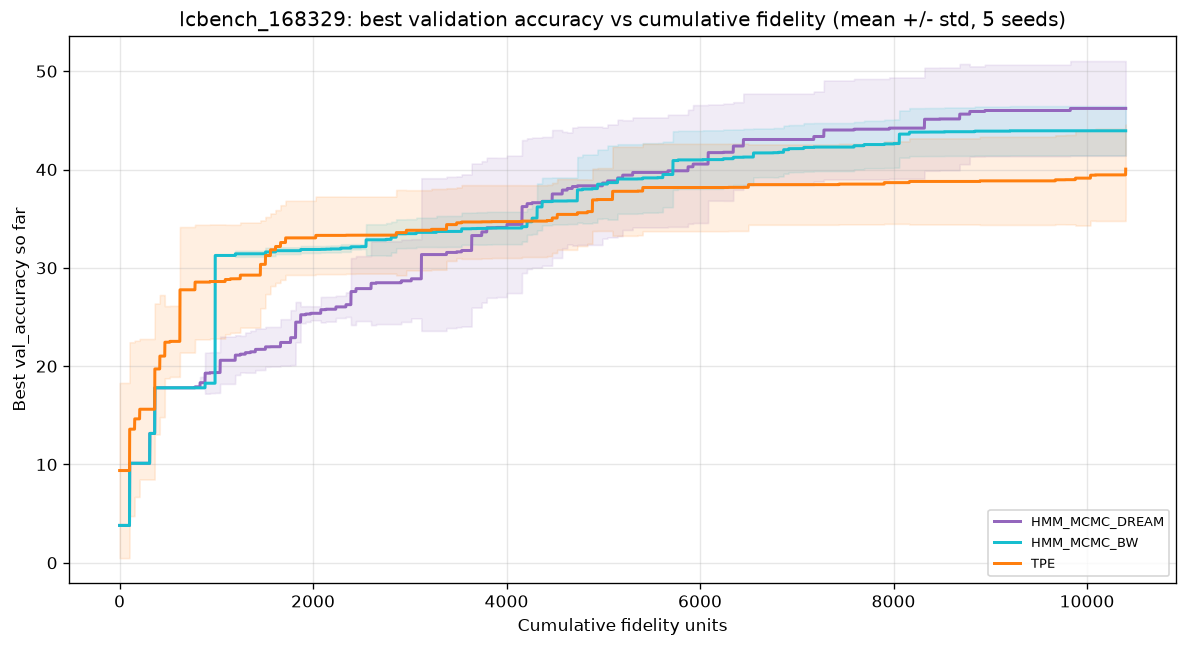

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\convergence_lcbench_168329.png


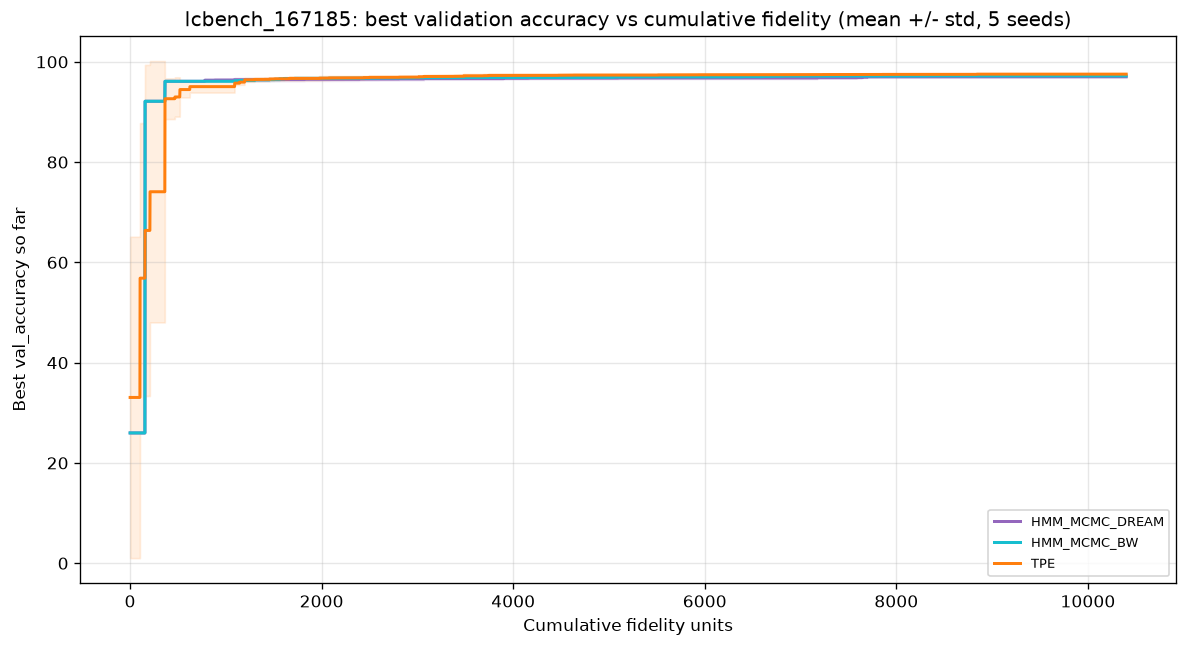

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\convergence_lcbench_167185.png


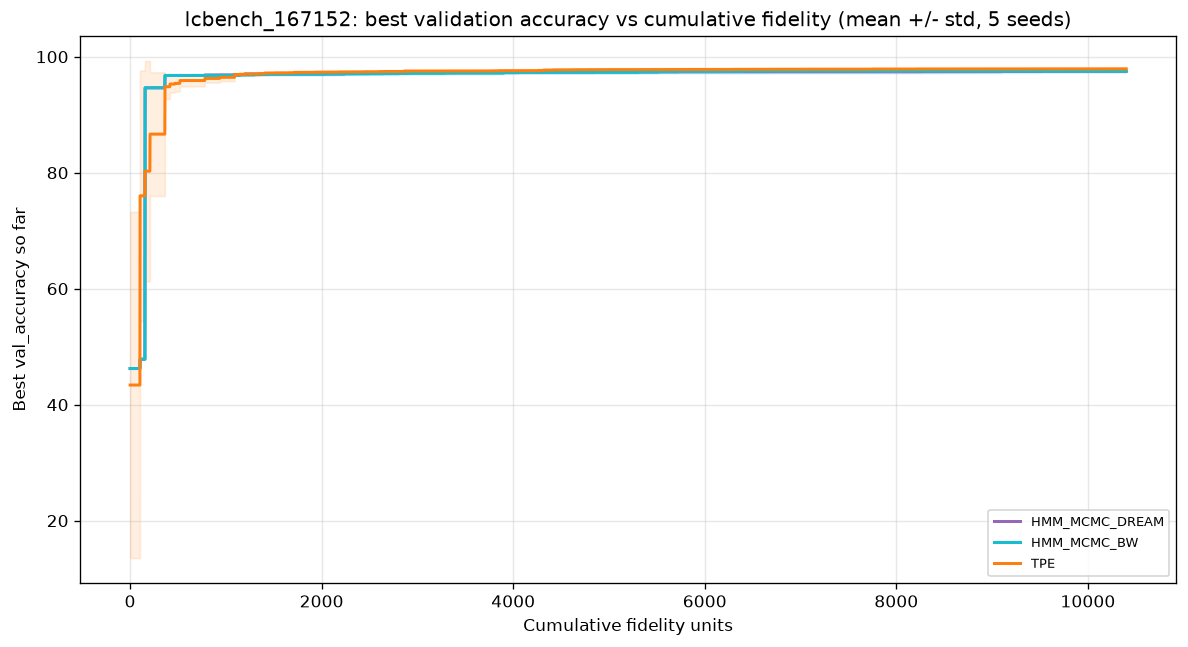

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\convergence_lcbench_167152.png


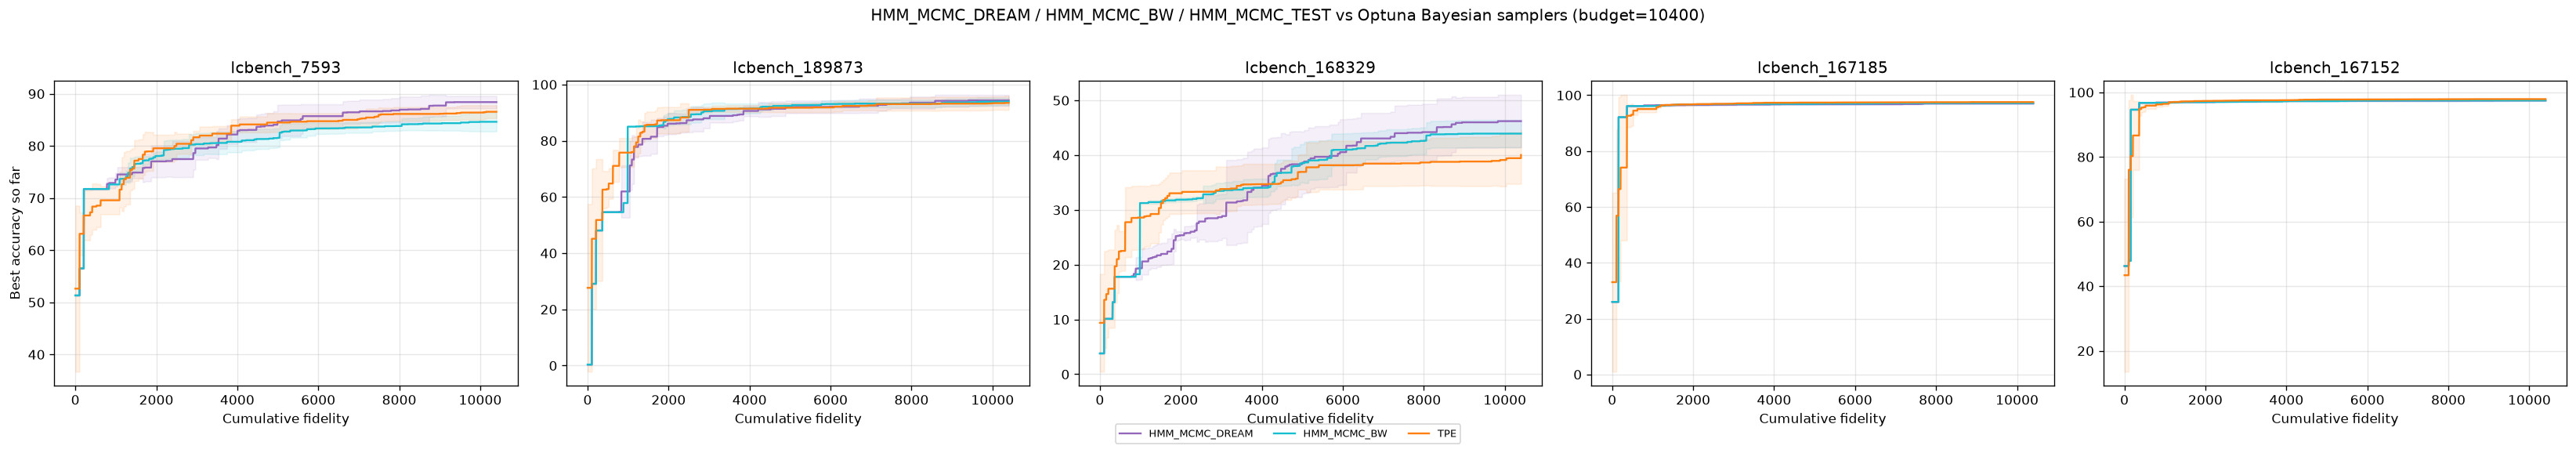

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\convergence_all.png


In [8]:
# =============================================================================
# Plotting
# =============================================================================

evals = np.arange(1, BUDGET_FIDELITY + 1)

for sc_key in SCENARIOS:
    n_algos = len(ALGORITHMS)
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for algo_name in ALGORITHMS:
        curves = results_curves[sc_key][algo_name]
        if not curves:
            continue
        mean, std = aggregate_curves(curves)
        color = ALGO_COLORS.get(algo_name, None)
        ax.plot(evals, mean, label=algo_name, color=color, linewidth=1.8)
        ax.fill_between(evals, mean - std, mean + std, color=color, alpha=0.12)

    ax.set_title(
        f"{sc_key}: best validation accuracy vs cumulative fidelity "
        f"(mean +/- std, {len(SEEDS)} seeds)"
    )
    ax.set_xlabel("Cumulative fidelity units")
    ax.set_ylabel(f"Best {contexts[sc_key].target} so far")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    out = PLOTS_DIR / f"convergence_{sc_key}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved {out}")

# Combined grid
ncols = len(SCENARIOS)
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.5), squeeze=False)
for col, sc_key in enumerate(SCENARIOS):
    ax = axes[0][col]
    for algo_name in ALGORITHMS:
        curves = results_curves[sc_key][algo_name]
        if not curves:
            continue
        mean, std = aggregate_curves(curves)
        color = ALGO_COLORS.get(algo_name, None)
        ax.plot(evals, mean, label=algo_name, color=color, linewidth=1.4)
        ax.fill_between(evals, mean - std, mean + std, color=color, alpha=0.10)
    ax.set_title(sc_key)
    ax.set_xlabel("Cumulative fidelity")
    if col == 0:
        ax.set_ylabel("Best accuracy so far")
    ax.grid(True, alpha=0.3)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    f"HMM_MCMC_DREAM / HMM_MCMC_BW / HMM_MCMC_TEST vs Optuna Bayesian samplers (budget={BUDGET_FIDELITY})",
    y=1.02,
)
fig.tight_layout()
combined = PLOTS_DIR / "convergence_all.png"
fig.savefig(combined, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved {combined}")


In [9]:
# =============================================================================
# Summary tables (CSV + LaTeX)
# =============================================================================
from IPython.display import display

rows = []
for sc_key in SCENARIOS:
    for algo_name in ALGORITHMS:
        vals = np.array(results_final[sc_key][algo_name], dtype=float)
        rows.append(
            {
                "scenario": sc_key,
                "algorithm": algo_name,
                "mean": float(np.nanmean(vals)),
                "std": float(np.nanstd(vals)),
                "best": float(np.nanmax(vals)),
                "worst": float(np.nanmin(vals)),
                "n_seeds": len(vals),
            }
        )

summary = pd.DataFrame(rows)
summary["rank"] = summary.groupby("scenario")["mean"].rank(ascending=False, method="average")

# Mean rank across scenarios
mean_ranks = (
    summary.groupby("algorithm")["rank"].mean().sort_values().reset_index()
)
mean_ranks.columns = ["algorithm", "mean_rank"]
print("\nMean rank across scenarios:\n", mean_ranks.to_string(index=False))

display(summary.sort_values(["scenario", "rank"]))

csv_path = RESULTS_DIR / "results_summary.csv"
tex_path = RESULTS_DIR / "results_summary.tex"
summary.to_csv(csv_path, index=False, float_format="%.6f")

with tex_path.open("w", encoding="utf-8") as fh:
    fh.write(summary.round(4).to_latex(index=False, escape=True))

print(f"Saved {csv_path}")
print(f"Saved {tex_path}")

# Pretty text table
print("\n" + "=" * 90)
print(f"{'Scenario':<14} {'Algorithm':<18} {'Mean+-Std':>18} {'Best':>10} {'Rank':>6}")
print("-" * 90)
for _, r in summary.sort_values(["scenario", "rank"]).iterrows():
    print(
        f"{r['scenario']:<14} {r['algorithm']:<18} "
        f"{r['mean']:8.4f} +- {r['std']:6.4f} {r['best']:10.4f} {int(r['rank']):>6}"
    )
print("=" * 90)



Mean rank across scenarios:
      algorithm  mean_rank
HMM_MCMC_DREAM        1.8
           TPE        2.0
   HMM_MCMC_BW        2.2


,scenario,algorithm,mean,std,best,worst,n_seeds,rank
14,lcbench_167152,TPE,97.905737,0.234356,98.135719,97.621201,5,1.0
13,lcbench_167152,HMM_MCMC_BW,97.504211,0.134321,97.761322,97.393562,5,2.0
12,lcbench_167152,HMM_MCMC_DREAM,97.482152,0.196759,97.845268,97.291077,5,3.0
11,lcbench_167185,TPE,97.544066,0.165382,97.784821,97.273262,5,1.0
10,lcbench_167185,HMM_MCMC_BW,97.189479,0.147418,97.296646,96.899208,5,2.0
9,lcbench_167185,HMM_MCMC_DREAM,97.018831,0.126933,97.190552,96.823090,5,3.0
6,lcbench_168329,HMM_MCMC_DREAM,46.212124,4.818828,50.373539,37.232704,5,1.0
7,lcbench_168329,HMM_MCMC_BW,43.937823,2.506657,46.158222,39.098286,5,2.0
8,lcbench_168329,TPE,40.039388,4.532255,47.787315,33.741554,5,3.0
3,lcbench_189873,HMM_MCMC_DREAM,94.375639,1.941405,96.762169,92.041336,5,1.0


Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\results_summary.csv
Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\results_summary.tex

Scenario       Algorithm                   Mean+-Std       Best   Rank
------------------------------------------------------------------------------------------
lcbench_167152 TPE                 97.9057 +- 0.2344    98.1357      1
lcbench_167152 HMM_MCMC_BW         97.5042 +- 0.1343    97.7613      2
lcbench_167152 HMM_MCMC_DREAM      97.4822 +- 0.1968    97.8453      3
lcbench_167185 TPE                 97.5441 +- 0.1654    97.7848      1
lcbench_167185 HMM_MCMC_BW         97.1895 +- 0.1474    97.2966      2
lcbench_167185 HMM_MCMC_DREAM      97.0188 +- 0.1269    97.1906      3
lcbench_168329 HMM_MCMC_DREAM      46.2121 +- 4.8188    50.3735      1
lcbench_168329 HMM_MCMC_BW         43.9378 +- 2.5067    46.1582      2
lcbench_168329 TPE                 40.0394 +- 4.5

## HMM variants on lcbench (3 OpenML instances)

Прямое сравнение HMM-алгоритмов на всех OpenML-dataset из основного прогона (`3945`, `7593`, `126026`).

- **HMM_MCMC_DREAM** — DREAM(ZS) + soft HMM + Baum-Welch (из основного эксперимента)
- **HMM_MCMC_RAM** — diagonal RAM on KDE mixture
- **HMM_MCMC_BW** — Baum-Welch + стандартные Gaussian/KDE proposals
- **HMM_MCMC_TEST** — Baum-Welch + spline proposals (из основного эксперимента)
- **HMM_MCMC** — базовый алгоритм (запускается здесь, если ещё не в кэше focus-секции)

**Выход:** `experiments/yahpo_plots/hmm_compare_*.png`, `experiments/yahpo_results/hmm_compare_summary.csv`

In [ ]:
# =============================================================================
# HMM_MCMC_TEST vs HMM_MCMC on lcbench (3 OpenML instances)
# =============================================================================
from IPython.display import display

HMM_COMPARE_ALGOS = ["HMM_MCMC_DREAM", "HMM_MCMC_GP_MALA", "HMM_MCMC_HMC", "HMM_MCMC_RAM", "HMM_MCMC_BW", "HMM_MCMC_TEST", "HMM_MCMC"]
HMM_COMPARE_COLORS = {
    "HMM_MCMC_DREAM": "#9467bd",
    "HMM_MCMC_GP_MALA": "#e377c2",
    "HMM_MCMC_HMC": "#8c564b",
    "HMM_MCMC_RAM": "#bcbd22",
    "HMM_MCMC_BW": "#17becf",
    "HMM_MCMC_TEST": "#1f77b4",
    "HMM_MCMC": "#2ca02c",
}
LCBENCH_SCENARIOS = [k for k in SCENARIOS if k.startswith("lcbench_")]

if "contexts" not in globals() or not contexts:
    contexts = {}
    for sc_key, sc_cfg in tqdm(
        list(SCENARIOS.items()),
        desc="Building scenario contexts",
        disable=not USE_TQDM,
    ):
        contexts[sc_key] = build_scenario_context(sc_key, sc_cfg)

hmm_curves: dict[str, dict[str, list[np.ndarray]]] = {
    sc: {algo: [] for algo in HMM_COMPARE_ALGOS} for sc in LCBENCH_SCENARIOS
}
hmm_final: dict[str, dict[str, list[float]]] = {
    sc: {algo: [] for algo in HMM_COMPARE_ALGOS} for sc in LCBENCH_SCENARIOS
}

# Load main experiment results if not in memory
if "results_curves" not in globals() or "results_final" not in globals():
    _cache_main = RESULTS_DIR / "raw_curves.npz"
    if _cache_main.is_file():
        _npz = np.load(_cache_main, allow_pickle=True)
        results_curves = {
            sc: {algo: [] for algo in ALGORITHMS} for sc in SCENARIOS
        }
        results_final = {
            sc: {algo: [] for algo in ALGORITHMS} for sc in SCENARIOS
        }
        for sc in SCENARIOS:
            for algo in ALGORITHMS:
                ck, fk = f"curve__{sc}__{algo}", f"final__{sc}__{algo}"
                if ck in _npz:
                    results_curves[sc][algo] = list(_npz[ck])
                if fk in _npz:
                    results_final[sc][algo] = list(_npz[fk])

for sc_key in LCBENCH_SCENARIOS:
    for algo in ("HMM_MCMC_DREAM", "HMM_MCMC_GP_MALA", "HMM_MCMC_RAM", "HMM_MCMC_BW", "HMM_MCMC_TEST"):
        algo_curves = results_curves.get(sc_key, {}).get(algo, [])
        algo_final = results_final.get(sc_key, {}).get(algo, [])
        if algo_curves:
            hmm_curves[sc_key][algo] = list(algo_curves)
            hmm_final[sc_key][algo] = list(algo_final)
            print(f"Reused {algo} on {sc_key} ({len(algo_final)} seeds)")

# Reuse HMM_MCMC from focus section or its cache
if "focus_curves" in globals() and "focus_final" in globals():
    for sc_key in LCBENCH_SCENARIOS:
        base_curves = focus_curves.get(sc_key, {}).get("HMM_MCMC", [])
        base_final = focus_final.get(sc_key, {}).get("HMM_MCMC", [])
        if base_curves:
            hmm_curves[sc_key]["HMM_MCMC"] = list(base_curves)
            hmm_final[sc_key]["HMM_MCMC"] = list(base_final)
            print(f"Reused HMM_MCMC from focus on {sc_key} ({len(base_final)} seeds)")

if any(not hmm_final[sc]["HMM_MCMC"] for sc in LCBENCH_SCENARIOS):
    _fcache = RESULTS_DIR / "focus_raw_curves.npz"
    if _fcache.is_file():
        _fnpz = np.load(_fcache, allow_pickle=True)
        for sc_key in LCBENCH_SCENARIOS:
            if hmm_final[sc_key]["HMM_MCMC"]:
                continue
            ck, fk = f"curve__{sc_key}__HMM_MCMC", f"final__{sc_key}__HMM_MCMC"
            if fk in _fnpz and len(_fnpz[fk]):
                hmm_curves[sc_key]["HMM_MCMC"] = list(_fnpz[ck])
                hmm_final[sc_key]["HMM_MCMC"] = list(_fnpz[fk])
                print(f"Loaded HMM_MCMC from focus cache on {sc_key}")

# Run missing HMM_MCMC baseline runs
hmm_runs = []
for sc_key in LCBENCH_SCENARIOS:
    n_done = len(hmm_final[sc_key]["HMM_MCMC"])
    if n_done < len(SEEDS):
        for seed in SEEDS[n_done:]:
            hmm_runs.append((sc_key, seed))

if hmm_runs:
    pbar = tqdm(hmm_runs, desc="HMM_MCMC baseline", unit="run", disable=not USE_TQDM)
    for sc_key, seed in pbar:
        ctx = contexts[sc_key]
        pbar.set_postfix(scenario=sc_key, seed=seed, refresh=False)
        events, best_val = run_hmm_mcmc(ctx, BUDGET_FIDELITY, seed)
        curve = events_to_best_curve(events, BUDGET_FIDELITY, maximize=True)
        hmm_curves[sc_key]["HMM_MCMC"].append(curve)
        hmm_final[sc_key]["HMM_MCMC"].append(best_val)

hmm_cache = RESULTS_DIR / "hmm_compare_raw_curves.npz"
np.savez(
    hmm_cache,
    scenarios=np.array(LCBENCH_SCENARIOS),
    algorithms=np.array(HMM_COMPARE_ALGOS),
    **{
        f"curve__{sc}__{algo}": np.vstack(hmm_curves[sc][algo])
        for sc in LCBENCH_SCENARIOS
        for algo in HMM_COMPARE_ALGOS
    },
    **{
        f"final__{sc}__{algo}": np.array(hmm_final[sc][algo])
        for sc in LCBENCH_SCENARIOS
        for algo in HMM_COMPARE_ALGOS
    },
)
print(f"Cached -> {hmm_cache}")

evals = np.arange(1, BUDGET_FIDELITY + 1)

for sc_key in LCBENCH_SCENARIOS:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    for algo_name in HMM_COMPARE_ALGOS:
        curves = hmm_curves[sc_key][algo_name]
        if not curves:
            continue
        mean, std = aggregate_curves(curves)
        color = HMM_COMPARE_COLORS[algo_name]
        ax.plot(evals, mean, label=algo_name, color=color, linewidth=2.0)
        ax.fill_between(evals, mean - std, mean + std, color=color, alpha=0.15)

    inst = SCENARIOS[sc_key]["instance"]
    ax.set_title(
        f"lcbench instance {inst}: HMM variants "
        f"(mean +/- std, {len(SEEDS)} seeds)"
    )
    ax.set_xlabel("Cumulative fidelity units")
    ax.set_ylabel(f"Best {contexts[sc_key].target} so far")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    out = PLOTS_DIR / f"hmm_compare_{sc_key}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved {out}")

ncols = len(LCBENCH_SCENARIOS)
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 4.5), sharey=True)
if ncols == 1:
    axes = [axes]
for col, sc_key in enumerate(LCBENCH_SCENARIOS):
    ax = axes[col]
    for algo_name in HMM_COMPARE_ALGOS:
        curves = hmm_curves[sc_key][algo_name]
        if not curves:
            continue
        mean, std = aggregate_curves(curves)
        color = HMM_COMPARE_COLORS[algo_name]
        ax.plot(evals, mean, label=algo_name, color=color, linewidth=1.8)
        ax.fill_between(evals, mean - std, mean + std, color=color, alpha=0.12)
    inst = SCENARIOS[sc_key]["instance"]
    ax.set_title(f"instance {inst}")
    ax.set_xlabel("Cumulative fidelity")
    if col == 0:
        ax.set_ylabel("Best accuracy so far")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("HMM_MCMC_DREAM / RAM / BW / TEST / BASE on lcbench", y=1.02)
fig.tight_layout()
combined = PLOTS_DIR / "hmm_compare_all.png"
fig.savefig(combined, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved {combined}")

hmm_rows = []
for sc_key in LCBENCH_SCENARIOS:
    for algo_name in HMM_COMPARE_ALGOS:
        vals = np.array(hmm_final[sc_key][algo_name], dtype=float)
        hmm_rows.append({
            "scenario": sc_key,
            "instance": SCENARIOS[sc_key]["instance"],
            "algorithm": algo_name,
            "mean": float(np.nanmean(vals)),
            "std": float(np.nanstd(vals)),
            "best": float(np.nanmax(vals)),
            "worst": float(np.nanmin(vals)),
            "n_seeds": len(vals),
        })

hmm_compare_summary = pd.DataFrame(hmm_rows)
hmm_compare_summary["rank"] = hmm_compare_summary.groupby("scenario")["mean"].rank(
    ascending=False, method="average"
)

delta_rows = []
for sc_key in LCBENCH_SCENARIOS:
    sub = hmm_compare_summary[hmm_compare_summary["scenario"] == sc_key]
    test_m = sub.loc[sub["algorithm"] == "HMM_MCMC_TEST", "mean"].iloc[0]
    base_m = sub.loc[sub["algorithm"] == "HMM_MCMC", "mean"].iloc[0]
    delta_rows.append({
        "scenario": sc_key,
        "instance": SCENARIOS[sc_key]["instance"],
        "mean_test": test_m,
        "mean_base": base_m,
        "delta_test_minus_base": test_m - base_m,
        "winner": "TEST" if test_m >= base_m else "BASE",
    })
hmm_delta = pd.DataFrame(delta_rows)

display(hmm_compare_summary.sort_values(["instance", "rank"]))
display(hmm_delta)

hmm_csv = RESULTS_DIR / "hmm_compare_summary.csv"
hmm_compare_summary.to_csv(hmm_csv, index=False, float_format="%.6f")
hmm_delta.to_csv(RESULTS_DIR / "hmm_compare_delta.csv", index=False, float_format="%.6f")
print(f"Saved {hmm_csv}")

print("\n" + "=" * 80)
print(f"{'Instance':<10} {'Algorithm':<18} {'Mean+-Std':>18} {'Best':>10} {'Rank':>6}")
print("-" * 80)
for _, r in hmm_compare_summary.sort_values(["instance", "rank"]).iterrows():
    print(
        f"{r['instance']:<10} {r['algorithm']:<18} "
        f"{r['mean']:8.4f} +- {r['std']:6.4f} {r['best']:10.4f} {int(r['rank']):>6}"
    )
print("-" * 80)
for _, r in hmm_delta.iterrows():
    sign = "+" if r["delta_test_minus_base"] >= 0 else ""
    print(
        f"instance {r['instance']}: TEST - BASE = {sign}{r['delta_test_minus_base']:.4f} "
        f"({r['winner']} wins)"
    )
print("=" * 80)

Reused HMM_MCMC_DREAM on lcbench_7593 (5 seeds)
Reused HMM_MCMC_BW on lcbench_7593 (5 seeds)
Reused HMM_MCMC_DREAM on lcbench_189873 (5 seeds)
Reused HMM_MCMC_BW on lcbench_189873 (5 seeds)
Reused HMM_MCMC_DREAM on lcbench_168329 (5 seeds)
Reused HMM_MCMC_BW on lcbench_168329 (5 seeds)
Reused HMM_MCMC_DREAM on lcbench_167185 (5 seeds)
Reused HMM_MCMC_BW on lcbench_167185 (5 seeds)
Reused HMM_MCMC_DREAM on lcbench_167152 (5 seeds)
Reused HMM_MCMC_BW on lcbench_167152 (5 seeds)


HMM_MCMC baseline:   0%|          | 0/25 [00:00<?, ?run/s]

HMM-base lcbench_7593 s=42:   0%|          | 0/200 [00:00<?, ?eval/s]

H-MCMC-FMP:   0%|          | 0/200 [00:00<?, ?it/s]


HMM MCMC State History (last run):
     Eval  Chain    State       Loss  Accepted  Rej_Streak
0      46      0  EXPLOIT -57.809532     False           1
1      47      0  EXPLOIT -67.749458     False           2
2      48      0  EXPLORE -75.309021      True           0
3      49      0  EXPLORE -78.251656      True           0
4      50      0  EXPLORE -76.004707     False           1
5      51      0  EXPLORE -66.058975     False           2
6      52      0  EXPLORE -78.147995     False           3
7      53      0  EXPLOIT -73.066254     False           4
8      54      0  EXPLORE -74.528107     False           5
9      55      0  EXPLORE -77.149940     False           6
10     56      0  EXPLOIT -78.565125      True           0
11     57      0  EXPLOIT -71.082123     False           1
12     58      0  EXPLORE -78.765121      True           0
13     59      0  EXPLOIT -74.376160     False           1
14     60      0  EXPLORE -79.347618      True           0
15     61      0  EX

...

HMM-base lcbench_167152 s=46:   0%|          | 0/200 [00:00<?, ?eval/s]

H-MCMC-FMP:   0%|          | 0/200 [00:00<?, ?it/s]


HMM MCMC State History (last run):
     Eval  Chain    State       Loss  Accepted  Rej_Streak
0      46      0  EXPLOIT -97.382050      True           0
1      47      0  EXPLOIT -97.069763     False           1
2      48      0  EXPLOIT -96.725998     False           2
3      49      0  EXPLOIT -97.382050      True           0
4      50      0  EXPLOIT -96.952080     False           1
5      51      0  EXPLOIT -96.786530     False           2
6      52      0  EXPLOIT -96.748512     False           3
7      53      0  EXPLOIT -96.833061     False           4
8      54      0  EXPLOIT -96.714195      True           0
9      55      0  EXPLOIT -96.853378      True           0
10     56      0  EXPLOIT -96.450027      True           0
11     57      0  EXPLOIT -95.887642     False           1
12     58      0  EXPLOIT -95.800255     False           2
13     59      0  EXPLOIT -95.786369     False           3
14     60      0  EXPLOIT -96.198692     False           4
15     61      0  EX

ValueError: need at least one array to concatenate

: 

## Outputs and next steps

After a successful run you should have:

| Artifact | Path |
|---|---|
| Per-scenario convergence plots | `experiments/yahpo_plots/convergence_<scenario>.png` |
| Combined plot | `experiments/yahpo_plots/convergence_all.png` |
| Summary table (CSV) | `experiments/yahpo_results/results_summary.csv` |
| Summary table (LaTeX) | `experiments/yahpo_results/results_summary.tex` |
| Raw curves cache | `experiments/yahpo_results/raw_curves.npz` |
| **HMM compare plots** | `experiments/yahpo_plots/hmm_compare_<scenario>.png`, `hmm_compare_all.png` |
| **HMM compare summary** | `experiments/yahpo_results/hmm_compare_summary.csv`, `hmm_compare_delta.csv` |
| **Focus comparison plots** | `experiments/yahpo_plots/focus_convergence_<scenario>.png` |
| **Focus summary (CSV/LaTeX)** | `experiments/yahpo_results/focus_summary.csv` / `.tex` |

**Progress bars (`tqdm`):**
- `USE_TQDM = True` — общий прогресс по всем runs + внутренние bars для Optuna/HMM
- `HMM_INNER_PROGRESS = True` — оставить встроенный tqdm HMM_MCMC_TEST вместо внешнего eval-bar

**For the final paper run:**
1. Set `SMOKE_MODE = False` in the config cell.
2. Ensure `yahpo_data` is fully cloned (~several GB).
3. Increase `BUDGET_FIDELITY` and `SEEDS` as needed.
4. Re-run all cells top-to-bottom.


## Focused comparison: TPE+Hyperband vs HMM variants

Четырёхстороннее сравнение для статьи:
- **TPE+Hyperband** — сильный multi-fidelity baseline Optuna
- **HMM_MCMC_DREAM** — DREAM(ZS) + soft HMM + Baum-Welch
- **HMM_MCMC_RAM** — diagonal RAM on KDE mixture
- **HMM_MCMC_BW** — Baum-Welch + стандартные Gaussian/KDE proposals
- **HMM_MCMC_TEST** — Baum-Welch + spline proposals
- **HMM_MCMC** — базовый алгоритм без BW/spline

Если основной эксперимент уже выполнен, результаты `TPE+Hyperband`, `HMM_MCMC_DREAM`, `HMM_MCMC_BW` и `HMM_MCMC_TEST` переиспользуются; запускается только `HMM_MCMC`.

**Выход:** `experiments/yahpo_plots/focus_*.png`, `experiments/yahpo_results/focus_summary.csv`

In [ ]:
# =============================================================================
# Focused 3-way comparison
# =============================================================================

FOCUS_ALGOS = ["TPE+Hyperband", "HMM_MCMC_DREAM", "HMM_MCMC_GP_MALA", "HMM_MCMC_HMC", "HMM_MCMC_RAM", "HMM_MCMC_BW", "HMM_MCMC_TEST", "HMM_MCMC"]
FOCUS_COLORS = {
    "TPE+Hyperband": "#ffbb78",
    "HMM_MCMC_DREAM": "#9467bd",
    "HMM_MCMC_GP_MALA": "#e377c2",
    "HMM_MCMC_HMC": "#8c564b",
    "HMM_MCMC_RAM": "#bcbd22",
    "HMM_MCMC_BW": "#17becf",
    "HMM_MCMC_TEST": "#1f77b4",
    "HMM_MCMC": "#2ca02c",
}
FOCUS_TPE_SPEC = {"kind": "optuna", "sampler": "TPE", "pruner": True}

# Ensure scenario contexts exist
if "contexts" not in globals() or not contexts:
    contexts = {}
    for sc_key, sc_cfg in tqdm(
        list(SCENARIOS.items()),
        desc="Building scenario contexts",
        disable=not USE_TQDM,
    ):
        contexts[sc_key] = build_scenario_context(sc_key, sc_cfg)

focus_curves: dict[str, dict[str, list[np.ndarray]]] = {
    sc: {algo: [] for algo in FOCUS_ALGOS} for sc in SCENARIOS
}
focus_final: dict[str, dict[str, list[float]]] = {
    sc: {algo: [] for algo in FOCUS_ALGOS} for sc in SCENARIOS
}

# Reuse results from the main experiment when available (in-memory or npz cache)
_have_main = "results_curves" in globals() and "results_final" in globals()
if not _have_main:
    _cache_main = RESULTS_DIR / "raw_curves.npz"
    if _cache_main.is_file():
        _npz = np.load(_cache_main, allow_pickle=True)
        results_curves = {
            sc: {algo: [] for algo in ALGORITHMS} for sc in SCENARIOS
        }
        results_final = {
            sc: {algo: [] for algo in ALGORITHMS} for sc in SCENARIOS
        }
        for sc in SCENARIOS:
            for algo in ALGORITHMS:
                ck = f"curve__{sc}__{algo}"
                fk = f"final__{sc}__{algo}"
                if ck in _npz:
                    results_curves[sc][algo] = list(_npz[ck])
                if fk in _npz:
                    results_final[sc][algo] = list(_npz[fk])
        _have_main = True
        print(f"Loaded main results from {_cache_main}")

# Resume partial focus runs from cache
_focus_cache = RESULTS_DIR / "focus_raw_curves.npz"
if _focus_cache.is_file():
    _fnpz = np.load(_focus_cache, allow_pickle=True)
    for sc in SCENARIOS:
        for algo in FOCUS_ALGOS:
            ck = f"curve__{sc}__{algo}"
            fk = f"final__{sc}__{algo}"
            if fk in _fnpz and len(_fnpz[fk]):
                focus_curves[sc][algo] = list(_fnpz[ck])
                focus_final[sc][algo] = list(_fnpz[fk])
                print(f"Resumed {algo} on {sc} ({len(focus_final[sc][algo])} seeds)")

for sc_key in SCENARIOS:
    for algo in ("TPE+Hyperband", "HMM_MCMC_DREAM", "HMM_MCMC_GP_MALA", "HMM_MCMC_RAM", "HMM_MCMC_BW", "HMM_MCMC_TEST"):
        if _have_main and results_curves.get(sc_key, {}).get(algo):
            focus_curves[sc_key][algo] = list(results_curves[sc_key][algo])
            focus_final[sc_key][algo] = list(results_final[sc_key][algo])
            print(f"Reused {algo} on {sc_key} ({len(focus_final[sc_key][algo])} seeds)")

focus_runs = []
for sc_key in SCENARIOS:
    for algo_name in FOCUS_ALGOS:
        n_done = len(focus_final[sc_key][algo_name])
        if n_done >= len(SEEDS):
            continue
        for seed in SEEDS[n_done:]:
            focus_runs.append((sc_key, algo_name, seed))

if focus_runs:
    pbar = tqdm(focus_runs, desc="Focus comparison", unit="run", disable=not USE_TQDM)
    for sc_key, algo_name, seed in pbar:
        ctx = contexts[sc_key]
        pbar.set_postfix(scenario=sc_key, algo=algo_name, seed=seed, refresh=False)
        if algo_name == "TPE+Hyperband":
            events, best_val = run_optuna(
                ctx, BUDGET_FIDELITY, seed,
                sampler_name=FOCUS_TPE_SPEC["sampler"],
                use_pruner=FOCUS_TPE_SPEC["pruner"],
            )
        elif algo_name == "HMM_MCMC_DREAM":
            events, best_val = run_hmm_mcmc_dream(ctx, BUDGET_FIDELITY, seed)
        elif algo_name == "HMM_MCMC_RAM":
            events, best_val = run_hmm_mcmc_ram(ctx, BUDGET_FIDELITY, seed)
        elif algo_name == "HMM_MCMC_GP_MALA":
            events, best_val = run_hmm_mcmc_gp_mala(ctx, BUDGET_FIDELITY, seed)
        elif algo_name == "HMM_MCMC_HMC":
            events, best_val = run_hmm_mcmc_hmc(ctx, BUDGET_FIDELITY, seed)
        elif algo_name == "HMM_MCMC_BW":
            events, best_val = run_hmm_mcmc_bw(ctx, BUDGET_FIDELITY, seed)
        elif algo_name == "HMM_MCMC_TEST":
            events, best_val = run_hmm_mcmc_test(ctx, BUDGET_FIDELITY, seed)
        else:
            events, best_val = run_hmm_mcmc(ctx, BUDGET_FIDELITY, seed)
        curve = events_to_best_curve(events, BUDGET_FIDELITY, maximize=True)
        focus_curves[sc_key][algo_name].append(curve)
        focus_final[sc_key][algo_name].append(best_val)
        pbar.set_postfix(
            scenario=sc_key, algo=algo_name, seed=seed, best=f"{best_val:.4f}", refresh=True
        )
else:
    print("All focus results loaded from main experiment.")

focus_cache = RESULTS_DIR / "focus_raw_curves.npz"
np.savez_compressed(
    focus_cache,
    budget_fidelity=BUDGET_FIDELITY,
    seeds=np.array(SEEDS),
    scenarios=np.array(list(SCENARIOS.keys())),
    algorithms=np.array(FOCUS_ALGOS),
    **{
        f"curve__{sc}__{algo}": np.vstack(focus_curves[sc][algo])
        for sc in SCENARIOS
        for algo in FOCUS_ALGOS
    },
    **{
        f"final__{sc}__{algo}": np.array(focus_final[sc][algo])
        for sc in SCENARIOS
        for algo in FOCUS_ALGOS
    },
)
print(f"Cached focus curves -> {focus_cache}")

Resumed TPE+Hyperband on lcbench_3945 (5 seeds)
Resumed HMM_MCMC_DREAM on lcbench_3945 (5 seeds)
Resumed HMM_MCMC_TEST on lcbench_3945 (5 seeds)
Resumed HMM_MCMC on lcbench_3945 (5 seeds)
Resumed TPE+Hyperband on lcbench_7593 (5 seeds)
Resumed HMM_MCMC_DREAM on lcbench_7593 (5 seeds)
Resumed HMM_MCMC_TEST on lcbench_7593 (5 seeds)
Resumed HMM_MCMC on lcbench_7593 (5 seeds)
Resumed TPE+Hyperband on lcbench_126026 (5 seeds)
Resumed HMM_MCMC_DREAM on lcbench_126026 (5 seeds)
Resumed HMM_MCMC_TEST on lcbench_126026 (5 seeds)
Resumed HMM_MCMC on lcbench_126026 (5 seeds)
Reused TPE+Hyperband on lcbench_3945 (5 seeds)
Reused HMM_MCMC_DREAM on lcbench_3945 (5 seeds)
Reused HMM_MCMC_TEST on lcbench_3945 (5 seeds)
Reused TPE+Hyperband on lcbench_7593 (5 seeds)
Reused HMM_MCMC_DREAM on lcbench_7593 (5 seeds)
Reused HMM_MCMC_TEST on lcbench_7593 (5 seeds)
Reused TPE+Hyperband on lcbench_126026 (5 seeds)
Reused HMM_MCMC_DREAM on lcbench_126026 (5 seeds)
Reused HMM_MCMC_TEST on lcbench_126026 (5 see

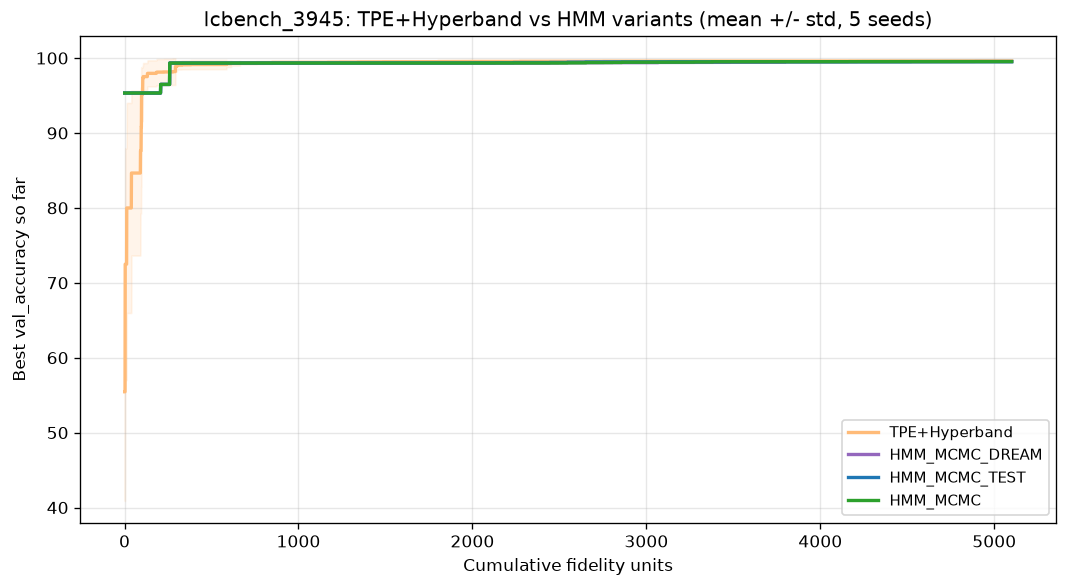

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\focus_convergence_lcbench_3945.png


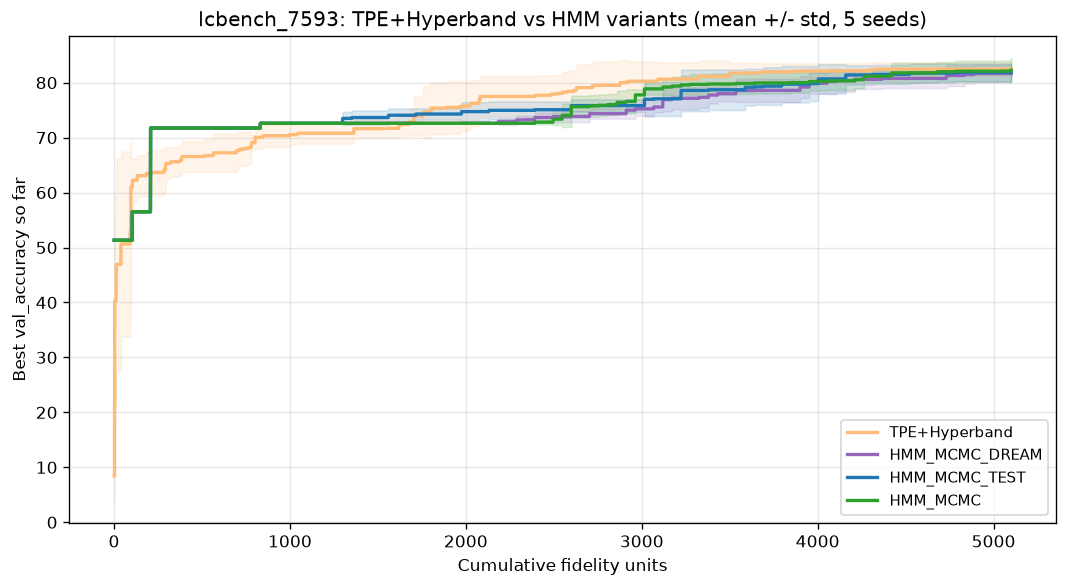

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\focus_convergence_lcbench_7593.png


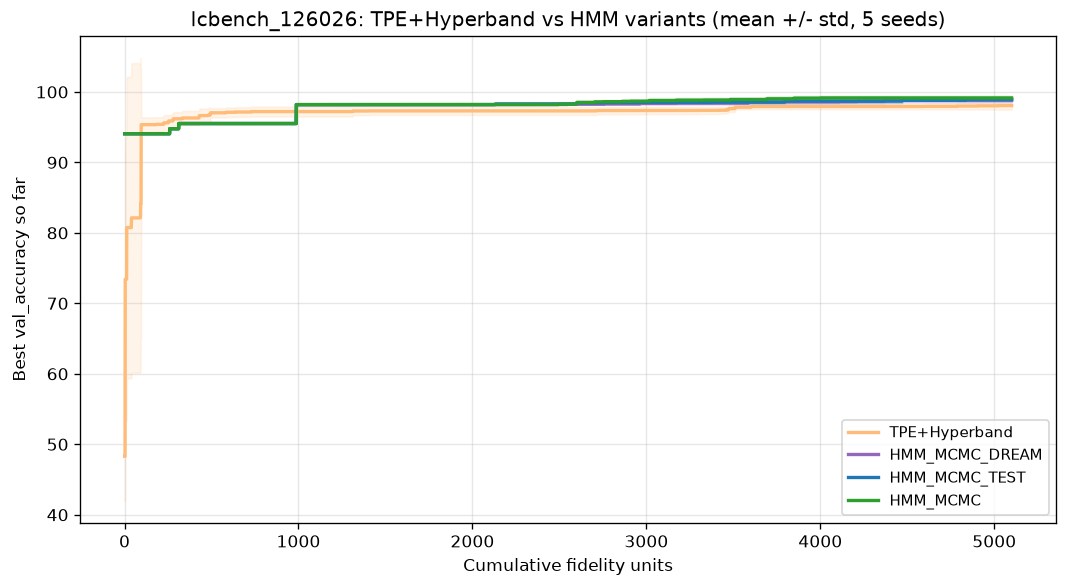

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\focus_convergence_lcbench_126026.png


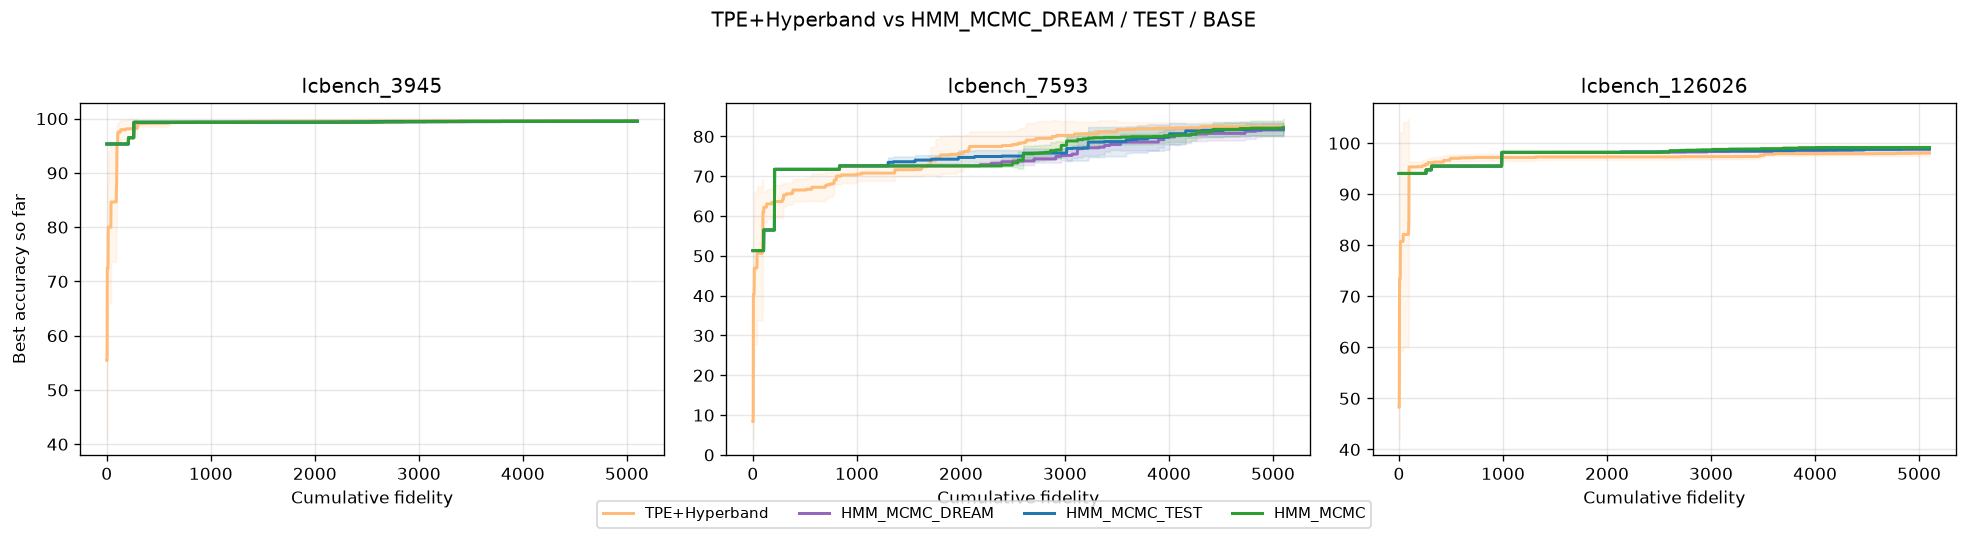

Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_plots\focus_convergence_all.png


,scenario,algorithm,mean,std,best,worst,n_seeds,rank
11,lcbench_126026,HMM_MCMC,99.146126,0.305190,99.438065,98.576576,5,1.0
10,lcbench_126026,HMM_MCMC_TEST,98.909070,0.230479,99.155487,98.546875,5,2.0
9,lcbench_126026,HMM_MCMC_DREAM,98.816939,0.324955,99.141876,98.199005,5,3.0
8,lcbench_126026,TPE+Hyperband,98.074115,0.606249,99.115784,97.410286,5,4.0
0,lcbench_3945,TPE+Hyperband,99.607927,0.039321,99.635887,99.530663,5,1.0
1,lcbench_3945,HMM_MCMC_DREAM,99.532826,0.088405,99.609283,99.360329,5,2.0
3,lcbench_3945,HMM_MCMC,99.531731,0.030862,99.580032,99.499153,5,3.0
2,lcbench_3945,HMM_MCMC_TEST,99.516623,0.042673,99.588768,99.466515,5,4.0
4,lcbench_7593,TPE+Hyperband,82.660867,1.110173,84.546333,81.122772,5,1.0
7,lcbench_7593,HMM_MCMC,82.278781,2.148785,85.889542,79.750908,5,2.0


Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\focus_summary.csv
Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\focus_summary.tex

Scenario       Algorithm                   Mean+-Std       Best   Rank
--------------------------------------------------------------------------------
lcbench_126026 HMM_MCMC            99.1461 +- 0.3052    99.4381      1
lcbench_126026 HMM_MCMC_TEST       98.9091 +- 0.2305    99.1555      2
lcbench_126026 HMM_MCMC_DREAM      98.8169 +- 0.3250    99.1419      3
lcbench_126026 TPE+Hyperband       98.0741 +- 0.6062    99.1158      4
lcbench_3945   TPE+Hyperband       99.6079 +- 0.0393    99.6359      1
lcbench_3945   HMM_MCMC_DREAM      99.5328 +- 0.0884    99.6093      2
lcbench_3945   HMM_MCMC            99.5317 +- 0.0309    99.5800      3
lcbench_3945   HMM_MCMC_TEST       99.5166 +- 0.0427    99.5888      4
lcbench_7593   TPE+Hyperband       82.6609 +- 1.1102    84.5463

In [ ]:
# =============================================================================
# Focus comparison: plots + table
# =============================================================================

evals = np.arange(1, BUDGET_FIDELITY + 1)

for sc_key in SCENARIOS:
    fig, ax = plt.subplots(figsize=(9, 5))
    for algo_name in FOCUS_ALGOS:
        curves = focus_curves[sc_key][algo_name]
        if not curves:
            continue
        mean, std = aggregate_curves(curves)
        color = FOCUS_COLORS[algo_name]
        ax.plot(evals, mean, label=algo_name, color=color, linewidth=2.0)
        ax.fill_between(evals, mean - std, mean + std, color=color, alpha=0.15)

    ax.set_title(
        f"{sc_key}: TPE+Hyperband vs HMM variants "
        f"(mean +/- std, {len(SEEDS)} seeds)"
    )
    ax.set_xlabel("Cumulative fidelity units")
    ax.set_ylabel(f"Best {contexts[sc_key].target} so far")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    out = PLOTS_DIR / f"focus_convergence_{sc_key}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved {out}")

ncols = len(SCENARIOS)
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.2), squeeze=False)
for col, sc_key in enumerate(SCENARIOS):
    ax = axes[0][col]
    for algo_name in FOCUS_ALGOS:
        curves = focus_curves[sc_key][algo_name]
        if not curves:
            continue
        mean, std = aggregate_curves(curves)
        color = FOCUS_COLORS[algo_name]
        ax.plot(evals, mean, label=algo_name, color=color, linewidth=1.8)
        ax.fill_between(evals, mean - std, mean + std, color=color, alpha=0.12)
    ax.set_title(sc_key)
    ax.set_xlabel("Cumulative fidelity")
    if col == 0:
        ax.set_ylabel("Best accuracy so far")
    ax.grid(True, alpha=0.3)
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("TPE+Hyperband vs HMM_MCMC_DREAM / TEST / BASE", y=1.02)
fig.tight_layout()
combined = PLOTS_DIR / "focus_convergence_all.png"
fig.savefig(combined, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved {combined}")

focus_rows = []
for sc_key in SCENARIOS:
    for algo_name in FOCUS_ALGOS:
        vals = np.array(focus_final[sc_key][algo_name], dtype=float)
        focus_rows.append({
            "scenario": sc_key,
            "algorithm": algo_name,
            "mean": float(np.nanmean(vals)),
            "std": float(np.nanstd(vals)),
            "best": float(np.nanmax(vals)),
            "worst": float(np.nanmin(vals)),
            "n_seeds": len(vals),
        })

focus_summary = pd.DataFrame(focus_rows)
focus_summary["rank"] = focus_summary.groupby("scenario")["mean"].rank(
    ascending=False, method="average"
)

display(focus_summary.sort_values(["scenario", "rank"]))

focus_csv = RESULTS_DIR / "focus_summary.csv"
focus_tex = RESULTS_DIR / "focus_summary.tex"
focus_summary.to_csv(focus_csv, index=False, float_format="%.6f")
with focus_tex.open("w", encoding="utf-8") as fh:
    fh.write(focus_summary.round(4).to_latex(index=False, escape=True))
print(f"Saved {focus_csv}")
print(f"Saved {focus_tex}")

print("\n" + "=" * 80)
print(f"{'Scenario':<14} {'Algorithm':<18} {'Mean+-Std':>18} {'Best':>10} {'Rank':>6}")
print("-" * 80)
for _, r in focus_summary.sort_values(["scenario", "rank"]).iterrows():
    print(
        f"{r['scenario']:<14} {r['algorithm']:<18} "
        f"{r['mean']:8.4f} +- {r['std']:6.4f} {r['best']:10.4f} {int(r['rank']):>6}"
    )
print("=" * 80)

## Summary tables (ranked by best seed)

Те же сводки, что выше, но **ранжирование по `best`** (лучший результат среди seeds), а не по `mean`.

Выход: `*_summary_best.csv` / `*_summary_best.tex` в `experiments/yahpo_results/`.

In [ ]:
# =============================================================================
# Summary tables ranked by BEST (not mean)
# =============================================================================
from IPython.display import display


def _load_main_results_from_cache():
    global results_final
    if "results_final" in globals() and results_final:
        return
    cache = RESULTS_DIR / "raw_curves.npz"
    if not cache.is_file():
        raise RuntimeError("Run the main experiment first (results_final missing).")
    _npz = np.load(cache, allow_pickle=True)
    results_final = {sc: {algo: [] for algo in ALGORITHMS} for sc in SCENARIOS}
    for sc in SCENARIOS:
        for algo in ALGORITHMS:
            fk = f"final__{sc}__{algo}"
            if fk in _npz:
                results_final[sc][algo] = list(_npz[fk])


def _load_hmm_compare_from_cache():
    global hmm_final, LCBENCH_SCENARIOS, HMM_COMPARE_ALGOS
    HMM_COMPARE_ALGOS = ["HMM_MCMC_DREAM", "HMM_MCMC_GP_MALA", "HMM_MCMC_HMC", "HMM_MCMC_RAM", "HMM_MCMC_BW", "HMM_MCMC_TEST", "HMM_MCMC"]
    LCBENCH_SCENARIOS = [k for k in SCENARIOS if k.startswith("lcbench_")]

    if (
        "hmm_final" in globals()
        and hmm_final
        and any(len(hmm_final[sc][algo]) for sc in LCBENCH_SCENARIOS for algo in HMM_COMPARE_ALGOS)
    ):
        return

    hmm_final = {
        sc: {algo: [] for algo in HMM_COMPARE_ALGOS} for sc in LCBENCH_SCENARIOS
    }

    _load_main_results_from_cache()
    for sc_key in LCBENCH_SCENARIOS:
        for algo in ("HMM_MCMC_DREAM", "HMM_MCMC_GP_MALA", "HMM_MCMC_RAM", "HMM_MCMC_BW", "HMM_MCMC_TEST"):
            vals = results_final.get(sc_key, {}).get(algo, [])
            if vals:
                hmm_final[sc_key][algo] = list(vals)

    fcache = RESULTS_DIR / "focus_raw_curves.npz"
    if fcache.is_file():
        _fnpz = np.load(fcache, allow_pickle=True)
        for sc_key in LCBENCH_SCENARIOS:
            fk = f"final__{sc_key}__HMM_MCMC"
            if fk in _fnpz and len(_fnpz[fk]):
                hmm_final[sc_key]["HMM_MCMC"] = list(_fnpz[fk])

    hcache = RESULTS_DIR / "hmm_compare_raw_curves.npz"
    if hcache.is_file():
        _hnpz = np.load(hcache, allow_pickle=True)
        for sc_key in LCBENCH_SCENARIOS:
            for algo in HMM_COMPARE_ALGOS:
                fk = f"final__{sc_key}__{algo}"
                if fk in _hnpz and len(_hnpz[fk]):
                    hmm_final[sc_key][algo] = list(_hnpz[fk])


def _load_focus_from_cache():
    global focus_final, FOCUS_ALGOS
    if "focus_final" in globals() and focus_final:
        return
    cache = RESULTS_DIR / "focus_raw_curves.npz"
    if not cache.is_file():
        raise RuntimeError("Run the focus comparison first (focus_final missing).")
    FOCUS_ALGOS = ["TPE+Hyperband", "HMM_MCMC_DREAM", "HMM_MCMC_GP_MALA", "HMM_MCMC_HMC", "HMM_MCMC_RAM", "HMM_MCMC_BW", "HMM_MCMC_TEST", "HMM_MCMC"]
    _npz = np.load(cache, allow_pickle=True)
    focus_final = {sc: {algo: [] for algo in FOCUS_ALGOS} for sc in SCENARIOS}
    for sc in SCENARIOS:
        for algo in FOCUS_ALGOS:
            fk = f"final__{sc}__{algo}"
            if fk in _npz:
                focus_final[sc][algo] = list(_npz[fk])


def _build_best_summary(final_dict, scenarios, algorithms, *, extra_fields=None):
    rows = []
    for sc_key in scenarios:
        for algo_name in algorithms:
            vals = np.array(final_dict[sc_key][algo_name], dtype=float)
            if len(vals) == 0:
                continue
            row = {
                "scenario": sc_key,
                "algorithm": algo_name,
                "mean": float(np.nanmean(vals)),
                "std": float(np.nanstd(vals)),
                "best": float(np.nanmax(vals)),
                "worst": float(np.nanmin(vals)),
                "n_seeds": len(vals),
            }
            if extra_fields:
                row.update(extra_fields(sc_key, algo_name))
            rows.append(row)
    df = pd.DataFrame(rows)
    df["rank"] = df.groupby("scenario")["best"].rank(ascending=False, method="average")
    return df


def _print_best_table(df, title, scenario_col="scenario"):
    print(f"\n{title}")
    print("=" * 90)
    print(f"{scenario_col:<14} {'Algorithm':<18} {'Best':>10} {'Mean+-Std':>18} {'Rank':>6}")
    print("-" * 90)
    sort_cols = ["scenario", "rank"] if scenario_col == "scenario" else [scenario_col, "rank"]
    for _, r in df.sort_values(sort_cols).iterrows():
        scen = r.get(scenario_col, r.get("scenario", ""))
        print(
            f"{str(scen):<14} {r['algorithm']:<18} "
            f"{r['best']:10.4f} {r['mean']:8.4f} +- {r['std']:6.4f} {int(r['rank']):>6}"
        )
    print("=" * 90)


def _save_best_summary(df, stem: str):
    csv_path = RESULTS_DIR / f"{stem}_best.csv"
    tex_path = RESULTS_DIR / f"{stem}_best.tex"
    df.to_csv(csv_path, index=False, float_format="%.6f")
    with tex_path.open("w", encoding="utf-8") as fh:
        fh.write(df.round(4).to_latex(index=False, escape=True))
    print(f"Saved {csv_path}")
    print(f"Saved {tex_path}")


# --- Main experiment (all algorithms) ---
_load_main_results_from_cache()
summary_best = _build_best_summary(results_final, SCENARIOS, ALGORITHMS)
best_ranks = (
    summary_best.groupby("algorithm")["rank"].mean().sort_values().reset_index()
)
best_ranks.columns = ["algorithm", "mean_rank_by_best"]
print("\nMean rank across scenarios (by best seed):\n", best_ranks.to_string(index=False))
display(summary_best.sort_values(["scenario", "rank"]))
_save_best_summary(summary_best, "results_summary")
_print_best_table(summary_best, "Main experiment — ranked by best seed")

# --- HMM compare (lcbench instances) ---
try:
    _load_hmm_compare_from_cache()
    hmm_compare_best = _build_best_summary(
        hmm_final,
        LCBENCH_SCENARIOS,
        HMM_COMPARE_ALGOS,
        extra_fields=lambda sc, _: {"instance": SCENARIOS[sc]["instance"]},
    )
    hmm_delta_best = []
    for sc_key in LCBENCH_SCENARIOS:
        sub = hmm_compare_best[hmm_compare_best["scenario"] == sc_key]
        test_b = sub.loc[sub["algorithm"] == "HMM_MCMC_TEST", "best"].iloc[0]
        base_b = sub.loc[sub["algorithm"] == "HMM_MCMC", "best"].iloc[0]
        hmm_delta_best.append({
            "scenario": sc_key,
            "instance": SCENARIOS[sc_key]["instance"],
            "best_test": test_b,
            "best_base": base_b,
            "delta_test_minus_base": test_b - base_b,
            "winner": "TEST" if test_b >= base_b else "BASE",
        })
    hmm_delta_best = pd.DataFrame(hmm_delta_best)

    display(hmm_compare_best.sort_values(["instance", "rank"]))
    display(hmm_delta_best)
    _save_best_summary(hmm_compare_best, "hmm_compare_summary")
    hmm_delta_best.to_csv(RESULTS_DIR / "hmm_compare_delta_best.csv", index=False, float_format="%.6f")
    print(f"Saved {RESULTS_DIR / 'hmm_compare_delta_best.csv'}")
    _print_best_table(hmm_compare_best, "HMM compare — ranked by best seed", scenario_col="instance")
    print("-" * 90)
    for _, r in hmm_delta_best.iterrows():
        sign = "+" if r["delta_test_minus_base"] >= 0 else ""
        print(
            f"instance {r['instance']}: TEST - BASE = {sign}{r['delta_test_minus_base']:.4f} "
            f"({r['winner']} wins by best seed)"
        )
except Exception as exc:
    print(f"Skipping HMM compare best tables: {exc}")

# --- Focus comparison ---
try:
    _load_focus_from_cache()
    focus_summary_best = _build_best_summary(focus_final, SCENARIOS, FOCUS_ALGOS)
    display(focus_summary_best.sort_values(["scenario", "rank"]))
    _save_best_summary(focus_summary_best, "focus_summary")
    _print_best_table(focus_summary_best, "Focus comparison — ranked by best seed")
except Exception as exc:
    print(f"Skipping focus best tables: {exc}")


Mean rank across scenarios (by best seed):
      algorithm  mean_rank_by_best
            GP           1.333333
 TPE+Hyperband           3.000000
           TPE           3.333333
HMM_MCMC_DREAM           3.666667
 HMM_MCMC_TEST           3.666667


,scenario,algorithm,mean,std,best,worst,n_seeds,rank
11,lcbench_126026,HMM_MCMC_TEST,99.610284,0.039372,99.665543,99.550407,5,1.0
14,lcbench_126026,GP,99.646078,0.017857,99.663261,99.624489,5,2.0
12,lcbench_126026,TPE,98.702321,0.834368,99.629051,97.607056,5,3.0
10,lcbench_126026,HMM_MCMC_DREAM,99.516861,0.058600,99.564461,99.416824,5,4.0
13,lcbench_126026,TPE+Hyperband,98.665787,0.552915,99.203537,97.600349,5,5.0
4,lcbench_3945,GP,99.656187,0.002300,99.657936,99.652237,5,1.0
3,lcbench_3945,TPE+Hyperband,99.644785,0.008532,99.655655,99.632088,5,2.0
2,lcbench_3945,TPE,99.638321,0.009257,99.647675,99.621445,5,3.0
0,lcbench_3945,HMM_MCMC_DREAM,99.575705,0.023211,99.613464,99.541672,5,4.0
1,lcbench_3945,HMM_MCMC_TEST,99.537274,0.025140,99.568260,99.507507,5,5.0


Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\results_summary_best.csv
Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\results_summary_best.tex

Main experiment — ranked by best seed
scenario       Algorithm                Best          Mean+-Std   Rank
------------------------------------------------------------------------------------------
lcbench_126026 HMM_MCMC_TEST         99.6655  99.6103 +- 0.0394      1
lcbench_126026 GP                    99.6633  99.6461 +- 0.0179      2
lcbench_126026 TPE                   99.6291  98.7023 +- 0.8344      3
lcbench_126026 HMM_MCMC_DREAM        99.5645  99.5169 +- 0.0586      4
lcbench_126026 TPE+Hyperband         99.2035  98.6658 +- 0.5529      5
lcbench_3945   GP                    99.6579  99.6562 +- 0.0023      1
lcbench_3945   TPE+Hyperband         99.6557  99.6448 +- 0.0085      2
lcbench_3945   TPE                   99.6477  99.6383 +- 0.0093      3
l

,scenario,algorithm,mean,std,best,worst,n_seeds,instance,rank
7,lcbench_126026,HMM_MCMC_TEST,99.610284,0.039372,99.665543,99.550407,5,126026,1.0
6,lcbench_126026,HMM_MCMC_DREAM,99.516861,0.058600,99.564461,99.416824,5,126026,2.0
8,lcbench_126026,HMM_MCMC,99.146126,0.305190,99.438065,98.576576,5,126026,3.0
0,lcbench_3945,HMM_MCMC_DREAM,99.575705,0.023211,99.613464,99.541672,5,3945,1.0
2,lcbench_3945,HMM_MCMC,99.531731,0.030862,99.580032,99.499153,5,3945,2.0
1,lcbench_3945,HMM_MCMC_TEST,99.537274,0.025140,99.568260,99.507507,5,3945,3.0
3,lcbench_7593,HMM_MCMC_DREAM,87.450143,1.320382,89.932182,86.019058,5,7593,1.0
4,lcbench_7593,HMM_MCMC_TEST,85.510300,1.443222,87.507080,83.021835,5,7593,2.0
5,lcbench_7593,HMM_MCMC,82.278781,2.148785,85.889542,79.750908,5,7593,3.0


,scenario,instance,best_test,best_base,delta_test_minus_base,winner
0,lcbench_3945,3945,99.568260,99.580032,-0.011772,BASE
1,lcbench_7593,7593,87.507080,85.889542,1.617538,TEST
2,lcbench_126026,126026,99.665543,99.438065,0.227478,TEST


Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\hmm_compare_summary_best.csv
Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\hmm_compare_summary_best.tex
Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\hmm_compare_delta_best.csv

HMM compare — ranked by best seed
instance       Algorithm                Best          Mean+-Std   Rank
------------------------------------------------------------------------------------------
126026         HMM_MCMC_TEST         99.6655  99.6103 +- 0.0394      1
126026         HMM_MCMC_DREAM        99.5645  99.5169 +- 0.0586      2
126026         HMM_MCMC              99.4381  99.1461 +- 0.3052      3
3945           HMM_MCMC_DREAM        99.6135  99.5757 +- 0.0232      1
3945           HMM_MCMC              99.5800  99.5317 +- 0.0309      2
3945           HMM_MCMC_TEST         99.5683  99.5373 +- 0.0251      3
7593           HMM_MCM

,scenario,algorithm,mean,std,best,worst,n_seeds,rank
11,lcbench_126026,HMM_MCMC,99.146126,0.305190,99.438065,98.576576,5,1.0
10,lcbench_126026,HMM_MCMC_TEST,98.909070,0.230479,99.155487,98.546875,5,2.0
9,lcbench_126026,HMM_MCMC_DREAM,98.816939,0.324955,99.141876,98.199005,5,3.0
8,lcbench_126026,TPE+Hyperband,98.074115,0.606249,99.115784,97.410286,5,4.0
0,lcbench_3945,TPE+Hyperband,99.607927,0.039321,99.635887,99.530663,5,1.0
1,lcbench_3945,HMM_MCMC_DREAM,99.532826,0.088405,99.609283,99.360329,5,2.0
2,lcbench_3945,HMM_MCMC_TEST,99.516623,0.042673,99.588768,99.466515,5,3.0
3,lcbench_3945,HMM_MCMC,99.531731,0.030862,99.580032,99.499153,5,4.0
7,lcbench_7593,HMM_MCMC,82.278781,2.148785,85.889542,79.750908,5,1.0
4,lcbench_7593,TPE+Hyperband,82.660867,1.110173,84.546333,81.122772,5,2.0


Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\focus_summary_best.csv
Saved c:\Users\Administrator\Documents\!prog\HPO_RL test\HPO_RL\experiments\yahpo_results\focus_summary_best.tex

Focus comparison — ranked by best seed
scenario       Algorithm                Best          Mean+-Std   Rank
------------------------------------------------------------------------------------------
lcbench_126026 HMM_MCMC              99.4381  99.1461 +- 0.3052      1
lcbench_126026 HMM_MCMC_TEST         99.1555  98.9091 +- 0.2305      2
lcbench_126026 HMM_MCMC_DREAM        99.1419  98.8169 +- 0.3250      3
lcbench_126026 TPE+Hyperband         99.1158  98.0741 +- 0.6062      4
lcbench_3945   TPE+Hyperband         99.6359  99.6079 +- 0.0393      1
lcbench_3945   HMM_MCMC_DREAM        99.6093  99.5328 +- 0.0884      2
lcbench_3945   HMM_MCMC_TEST         99.5888  99.5166 +- 0.0427      3
lcbench_3945   HMM_MCMC              99.5800  99.5317 +- 0.0309      4
lcbe